# __*NLP-Sentiment Analysis*__
### Amazon Customer Review Sentiment Analysis

**Business Objective:** Extract sentiment from Amazon customer reviews of a product, as the first step toward building models that automatically classify a review as **positive**, **neutral**, or **negative**.

**What this notebook does:**
1. Load the Amazon review dataset (1,440 reviews) and check data quality: missing values, duplicates, and data types

2. Derive the sentiment label from the star rating (1–2 negative, 3 neutral, 4–5 positive)

3. Explore class balance, review length, emojis, top words and bigrams, and word clouds for each sentiment

4. Combine title and body into one review column and clean the text (emojis, contractions, HTML, URLs, punctuation, stop words while keeping negations)

5. Build a TF-IDF baseline with Logistic Regression, Naive Bayes, and Linear SVM

6. Train deep learning models (SimpleRNN and LSTM) with class weights

7. Fine-tune a DistilBERT transformer

8. Compare all models on macro-F1, since the classes are imbalanced

9. Save the best model (TF-IDF + Logistic Regression pipeline) and the preprocessing.py module for the Streamlit app

## Exploratory Data Analysis (EDA)

In [1]:
# Import required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Load in Dataset
df= pd.read_excel(r"D:\Project_ExcelR\dataset.xlsx")

# shape of the dataset
print(f"Shape of Dataset: {df.shape[0]} rows, {df.shape[1]} columns")

df.head(10)

Shape of Dataset: 1440 rows, 3 columns


,title,rating,body
0,Horrible product,1,Very disappointed with the overall performance...
1,Camera quality is not like 48 megapixel,3,Camera quality is low
2,Overall,4,"Got the mobile on the launch date,Battery must..."
3,A big no from me,1,1. It doesn't work with 5.0GHz WiFi frequency....
4,Put your money somewhere else,1,"Not worth buying....faulty software, poor disp..."
5,Too much lagging and slow,1,I will never purchase Samsung phones. Phone is...
6,Worst samsung mobile ever,1,This is worst samsung mobile I have seen from ...
7,कैसा दिखाते है उसका 10 % भी नही,1,मोबाइल का कैमरा बिल्कुल भी सही नही है 48 PM बत...
8,Slow performance,1,The phone hangs a lot and is very slow. I rece...
9,Don’t buy from Amazon.,1,Very poor quality camera .Found box seal damag...


In [3]:
df['body'].values[9]

'Very poor quality camera .Found box seal damage still Amazon not taking it back.waste of money.Phone very slow.Don’t buy from Amazon.Now Amazon started cheating customers to make profits.'

### Data Quality Checks

In [4]:
df.info()  # it gives column names, dtypes and non-null counts in one shot

# info() shows this too, but a dedicated check makes it unmissable and easy to act on
print(f"\nMissing values per column:\n{df.isnull().sum()}")

# check for duplicate rows (same title + rating + body), repeated entries can bias a model if left in
print(f"\nDuplicated Rows: {df.duplicated().sum()}")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1440 entries, 0 to 1439
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   title   1440 non-null   object
 1   rating  1440 non-null   int64 
 2   body    1440 non-null   object
dtypes: int64(1), object(2)
memory usage: 33.9+ KB

Missing values per column:
title     0
rating    0
body      0
dtype: int64

Duplicated Rows: 0


### Derive the sentiment label
The dataset only gives us a star rating (1-5), not a ready-made sentiment label. So we create the sentiment label

| Rating | Sentiment |
|---|---|
| 1-2 stars | negative |
| 3 stars | neutral |
| 4-5 stars | positive |

In [5]:
df['sentiment']= df['rating'].apply(lambda x: 'positive' if x>= 4 
                                    else 'negative' if x<= 2 
                                    else 'neutral')

df[['rating', 'sentiment']].head(30)

,rating,sentiment
0,1,negative
1,3,neutral
2,4,positive
3,1,negative
4,1,negative
5,1,negative
6,1,negative
7,1,negative
8,1,negative
9,1,negative


### Class balance check - rating and sentiment

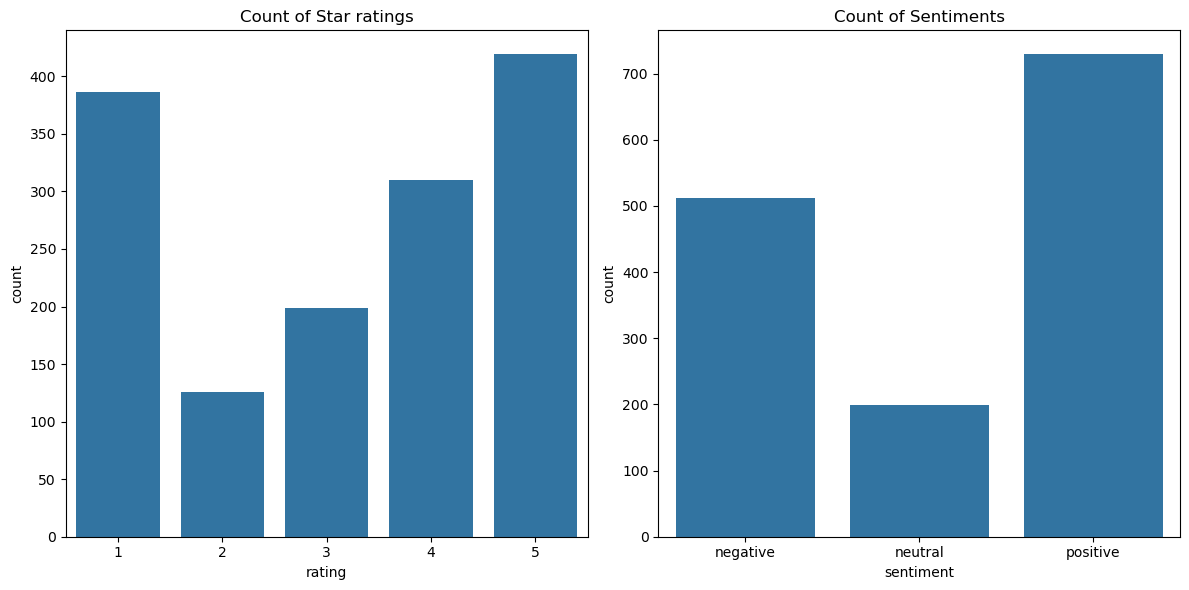

sentiment
positive    50.62%
negative    35.56%
neutral     13.82%
Name: count, dtype: object


In [6]:
fig, axes= plt.subplots(1, 2, figsize= (12, 6))
sns.countplot(data= df, x= 'rating', ax= axes[0])
axes[0].set_title('Count of Star ratings')

sns.countplot(data= df, x= 'sentiment', ax= axes[1])
axes[1].set_title('Count of Sentiments')
plt.tight_layout()
plt.show()

print((df['sentiment'].value_counts()/ len(df) * 100).map('{:.2f}%'.format))

**Reading the chart:** if one class (e.g. "neutral") has far fewer
examples than the others, our dataset is **imbalanced**. This matters
because a model can get high accuracy just by always predicting the
majority class, while being useless at spotting the minority class. We
will account for this when training and evaluating models (e.g. using class weights and looking at F1-score per class,
not just overall accuracy).

### Combine title + body into one column
- We don't overwrite __title__ and __body__ columns
- We create a new column called __full_review__ which is purely additional column
- At any point we can trace both cleand row to its original title and body it came from

In [7]:
df['full_review']= (df['title'].fillna('').astype(str)+' '+df['body'].fillna('').astype(str)).str.strip()

    # fillna(''): there is a missing value (NaN), replace it with an empty string.
    # astype(str): converts the values into string so we can easely add title and body
    # +' '+: it joins two columns with a space between them
    # srt.strip(): removes unwanted spaces from begining to end

# Check
df[['title', 'body', 'full_review']].head()

,title,body,full_review
0,Horrible product,Very disappointed with the overall performance...,Horrible product Very disappointed with the ov...
1,Camera quality is not like 48 megapixel,Camera quality is low,Camera quality is not like 48 megapixel Camera...
2,Overall,"Got the mobile on the launch date,Battery must...","Overall Got the mobile on the launch date,Batt..."
3,A big no from me,1. It doesn't work with 5.0GHz WiFi frequency....,A big no from me 1. It doesn't work with 5.0GH...
4,Put your money somewhere else,"Not worth buying....faulty software, poor disp...",Put your money somewhere else Not worth buying...


### Review length analysis
- Reviews with very few words often carry less information
- Reviews with very more words may be mix of multiple opinions (pros & cons)

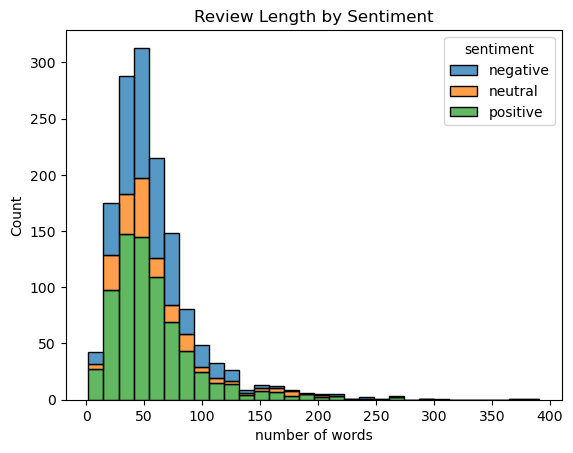

,mean,median,max
sentiment,,,
negative,57.957031,51.0,308
neutral,61.864322,46.0,391
positive,57.484225,48.0,297


In [8]:
# count the number of words in each review
df['word_count']= df['full_review'].str.split().str.len()

# visualize the review length by sentiment

sns.histplot(data= df, x= 'word_count', hue= 'sentiment', bins= 30, multiple= 'stack')
plt.title('Review Length by Sentiment')
plt.xlabel('number of words')
plt.show()

# summary table
df.groupby('sentiment')['word_count'].agg(['mean', 'median', 'max'])

In [9]:
# emoji analysis
import emoji
emojis= [e for review in df['full_review'] for e in review if emoji.is_emoji(e)]

print(len(emojis))
print(f"Unique Emojis: {set(emojis)}")

706
Unique Emojis: {'😔', '🙏', '👏', '💨', '😤', '🎤', '😍', '🐌', '❤', '👟', '🗣', '🔥', '🥰', '🕐', '🤗', '✅', '🥳', '👉', '⛷', '🌀', '🚑', '👇', '✍', '🎁', '🙂', '🤩', '👂', '🍦', '😶', '👀', '✌', '⭐', '🤟', '🔋', '😑', '💰', '🔘', '😊', '😢', '😳', '😏', '😁', '📸', '📱', '▪', '🏃', '👎', '🐢', '☹', '👍', '🏻', '😃', '😎', '🖖', '🎮', '💯', '🙄', '🤮', '🎱', '🤬', '🙁', '🤢', '🏼', '💛', '😒', '💗', '😅', '🌛', '💪', '😓', '😀', '😡', '👌', '😭', '📦', '🤔', '🏠', '🎯', '🍄', '🔴', '😄', '🚩', '😞', '🌾', '☺', '🔔', '😜', '❗', '🌟', '🕓', '😌', '🤡', '✨', '🔊', '😉', '🚒', '😱', '😘', '😪', '📷', '🤳', '😯', '☁', '😠', '✔', '🤣', '💓', '😂', '💖', '🎈', '🗑'}


### Clean the text
Raw, uncleaned text is full of noise that has nothing to do with sentiment, So we have to clean it

- We clean and use both __body__ and __full_review__ columns to see whether the title was actually adding value
- It becomes the main input to model

    `Cleaning:`
- lowercases text
- removing URLs/HTML tags, punctuation and digits
- stop words removal (while keeping negation words like 'not', 'never', 'do not')

In [10]:
import re
import string
import contractions
from nltk.corpus import stopwords

In [11]:
# getting english stopwords
stop_words1= set(stopwords.words('english'))

print(f'before removing negation words: {len(stop_words1)}')

# Words we want to keep for sentiment analysis
keep_words= {'not', 'no', 'nor', 'do', 'does', 'did'}

# Remove negation words from stop words
stop_words2= stop_words1 - keep_words

print(f'after removing negation words: {len(stop_words2)}')

before removing negation words: 198
after removing negation words: 192


In [12]:
# we are gonna use contractions library to expand the contractions to their full form
# didn't --> did not
# exaxample check
ex= "I didn't like quality of the product, and i don't recommend it to others"
contractions.fix(ex)

'I did not like quality of the product, and i do not recommend it to others'

In [13]:
# define a function to create a cleaned column
def clean_text(text):                                                 # we are creating a function called 'clean_text' and 'text' is the input

    text= emoji.demojize(text)                                        # convert emojis to descriptive text
    
    text= str(text).lower()                                           # str- coverts input into string, lower()- coverts uppercase letters to lowercase

    text= contractions.fix(text)                                      # automatically expand contractions 
    
    text= re.sub(r"<.*?>", " ", text)                                 # re.sub()- regular expression, finds patter and replace it with something else
                                                                      # <.*?>: is designed to find HTML tags
    
    text= re.sub(r"http\S+|www\S+"," " , text)                        # this removes web addresses
    
    for i in string.punctuation:                                      # removing punctuations and replacing with a space
        text= text.replace(i, ' ')

    text= re.sub(r"\s+", " ", text).strip()                           # removes extra spaces

    words1= text.split()                                              # split text into words

    words2= [word for word in words1 if word not in stop_words2]      # removing stop words

    text= " ".join(words2)                                            # join words again to a single string
    
    return text                                                       # return the cleaned text

In [14]:
# apply the function to data to clean the text
df['clean_review']= df['full_review'].apply(clean_text)

In [15]:
df.head(10)

,title,rating,body,sentiment,full_review,word_count,clean_review
0,Horrible product,1,Very disappointed with the overall performance...,negative,Horrible product Very disappointed with the ov...,10,horrible product disappointed overall performa...
1,Camera quality is not like 48 megapixel,3,Camera quality is low,neutral,Camera quality is not like 48 megapixel Camera...,11,camera quality not like 48 megapixel camera qu...
2,Overall,4,"Got the mobile on the launch date,Battery must...",positive,"Overall Got the mobile on the launch date,Batt...",67,overall got mobile launch date battery must ap...
3,A big no from me,1,1. It doesn't work with 5.0GHz WiFi frequency....,negative,A big no from me 1. It doesn't work with 5.0GH...,72,big no 1 does not work 5 0ghz wifi frequency 2...
4,Put your money somewhere else,1,"Not worth buying....faulty software, poor disp...",negative,Put your money somewhere else Not worth buying...,34,put money somewhere else not worth buying faul...
5,Too much lagging and slow,1,I will never purchase Samsung phones. Phone is...,negative,Too much lagging and slow I will never purchas...,23,much lagging slow never purchase samsung phone...
6,Worst samsung mobile ever,1,This is worst samsung mobile I have seen from ...,negative,Worst samsung mobile ever This is worst samsun...,37,worst samsung mobile ever worst samsung mobile...
7,कैसा दिखाते है उसका 10 % भी नही,1,मोबाइल का कैमरा बिल्कुल भी सही नही है 48 PM बत...,negative,कैसा दिखाते है उसका 10 % भी नही मोबाइल का कैमर...,37,कैसा दिखाते है उसका 10 भी नही मोबाइल का कैमरा ...
8,Slow performance,1,The phone hangs a lot and is very slow. I rece...,negative,Slow performance The phone hangs a lot and is ...,19,slow performance phone hangs lot slow received...
9,Don’t buy from Amazon.,1,Very poor quality camera .Found box seal damag...,negative,Don’t buy from Amazon. Very poor quality camer...,32,do not buy amazon poor quality camera found bo...


### Word Cloud Analysis by Sentiment

In [16]:
# find the most comman words
from collections import Counter

top_words= {}                   # storing top 20 words for each sentiment

for sentiment in ['positive', 'negative', 'neutral']:
    # combine all reviews of each sentiment
    reviews= ' '.join(df.loc[df['sentiment']== sentiment, 'clean_review'])

    # count words and get top 20
    top_words[sentiment]= Counter(reviews.split()).most_common(20)

    print(f"\nTop 20 {sentiment} Words:")
    print(top_words[sentiment])


Top 20 positive Words:
[('good', 1071), ('phone', 986), ('not', 628), ('battery', 607), ('camera', 602), ('quality', 346), ('price', 338), ('samsung', 325), ('mobile', 232), ('life', 225), ('best', 214), ('budget', 213), ('great', 208), ('product', 182), ('use', 171), ('display', 167), ('also', 161), ('2', 158), ('overall', 157), ('range', 156)]

Top 20 negative Words:
[('not', 949), ('phone', 642), ('samsung', 375), ('camera', 297), ('mobile', 290), ('quality', 250), ('do', 244), ('product', 224), ('buy', 217), ('worst', 198), ('good', 190), ('amazon', 186), ('battery', 177), ('face', 157), ('no', 132), ('poor', 129), ('bad', 120), ('also', 116), ('display', 115), ('like', 111)]

Top 20 neutral Words:
[('not', 366), ('phone', 260), ('good', 213), ('camera', 184), ('quality', 123), ('battery', 121), ('mobile', 106), ('samsung', 102), ('average', 79), ('price', 61), ('better', 50), ('heavy', 49), ('do', 48), ('2', 46), ('also', 45), ('no', 45), ('screen', 44), ('display', 43), ('perfor

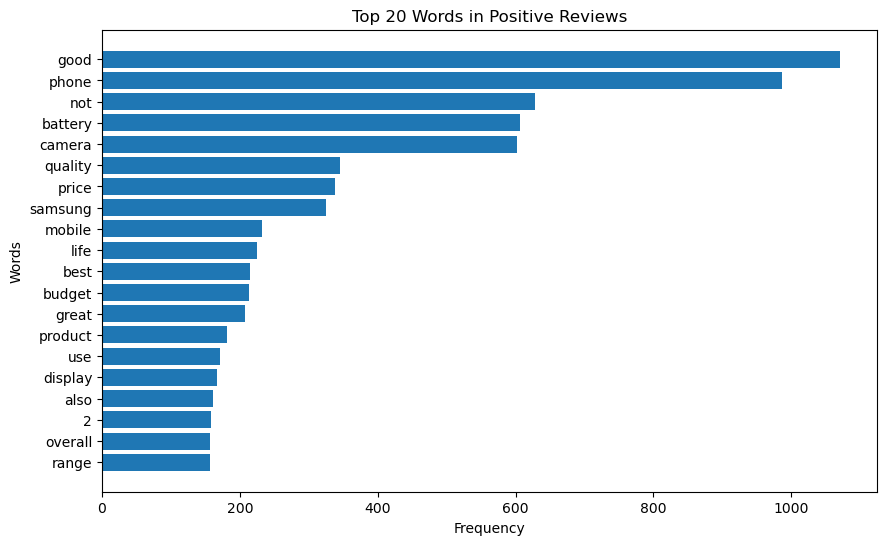

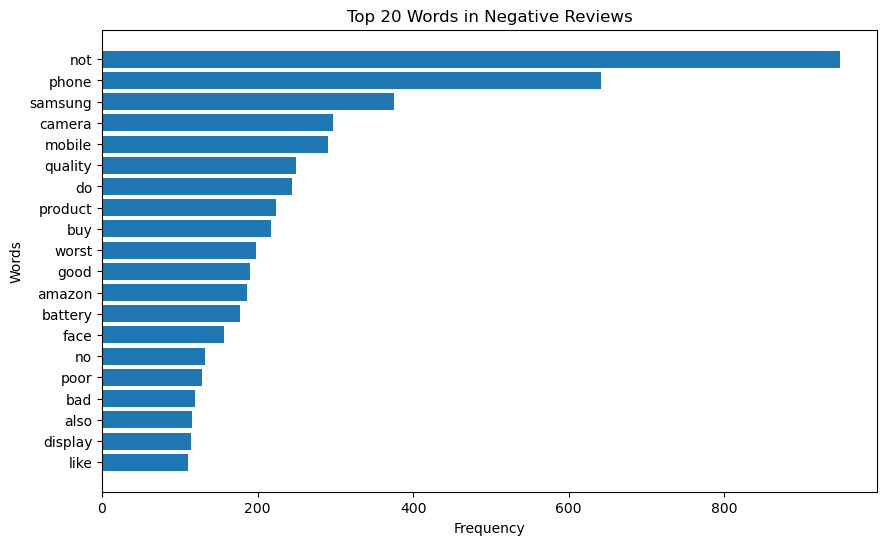

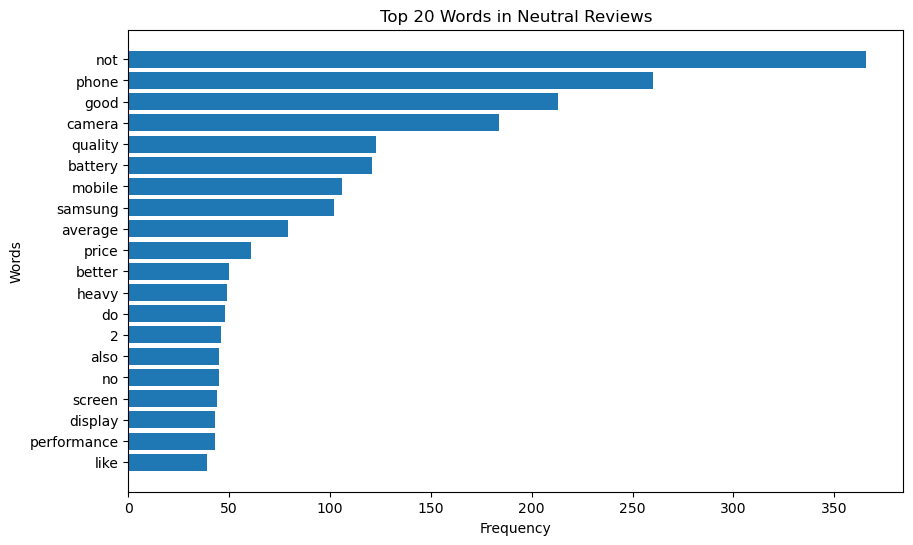

In [17]:
import matplotlib.pyplot as plt

for sentiment in ['positive', 'negative', 'neutral']:

    # Get words and their frequencies
    words = [item[0] for item in top_words[sentiment]]
    counts = [item[1] for item in top_words[sentiment]]

    # Create bar chart
    plt.figure(figsize=(10, 6))

    plt.barh(words, counts)

    plt.title(f'Top 20 Words in {sentiment.title()} Reviews')
    plt.xlabel('Frequency')
    plt.ylabel('Words')

    # Show highest frequency at the top
    plt.gca().invert_yaxis()

    plt.show()

In [18]:
from sklearn.feature_extraction.text import CountVectorizer

top_bigrams = {}

for sentiment in ['positive', 'negative', 'neutral']:

    # Get reviews for one sentiment
    reviews = df[df['sentiment'] == sentiment]['clean_review']

    # Create a bigram vectorizer
    vectorizer = CountVectorizer(ngram_range=(2, 2))

    # Find and count bigrams
    X = vectorizer.fit_transform(reviews)

    # Get bigram names
    bigrams = vectorizer.get_feature_names_out()

    # Get frequency of each bigram
    counts = X.sum(axis=0).A1

    # Combine bigrams with their frequencies
    bigram_counts = list(zip(bigrams, counts))

    # Sort and get top 20
    top_bigrams[sentiment] = sorted(
        bigram_counts,
        key=lambda x: x[1],
        reverse=True
    )[:20]

    print(f"\nTop 20 {sentiment.title()} Bigrams:")
    print(top_bigrams[sentiment])


Top 20 Positive Bigrams:
[('battery life', np.int64(205)), ('camera quality', np.int64(142)), ('price range', np.int64(94)), ('budget phone', np.int64(87)), ('do not', np.int64(85)), ('good phone', np.int64(82)), ('value money', np.int64(82)), ('good battery', np.int64(70)), ('battery backup', np.int64(66)), ('phone good', np.int64(64)), ('quality good', np.int64(58)), ('does not', np.int64(57)), ('not good', np.int64(55)), ('finger print', np.int64(53)), ('also good', np.int64(47)), ('fingerprint sensor', np.int64(45)), ('phone price', np.int64(45)), ('good camera', np.int64(44)), ('refresh rate', np.int64(42)), ('galaxy m12', np.int64(40))]

Top 20 Negative Bigrams:
[('do not', np.int64(227)), ('not buy', np.int64(125)), ('camera quality', np.int64(104)), ('does not', np.int64(80)), ('not good', np.int64(72)), ('smiling face', np.int64(63)), ('not working', np.int64(57)), ('cloud cloud', np.int64(47)), ('battery life', np.int64(45)), ('microphone microphone', np.int64(42)), ('smirki

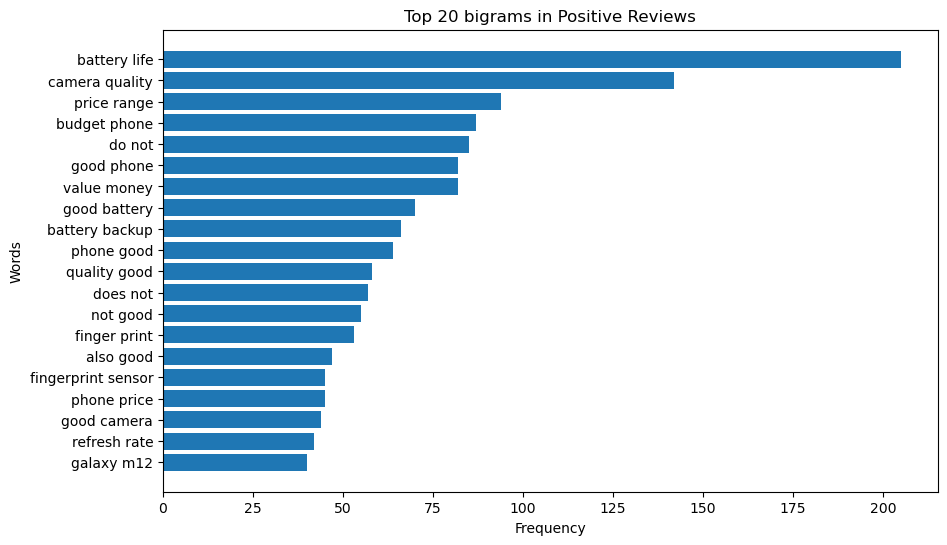

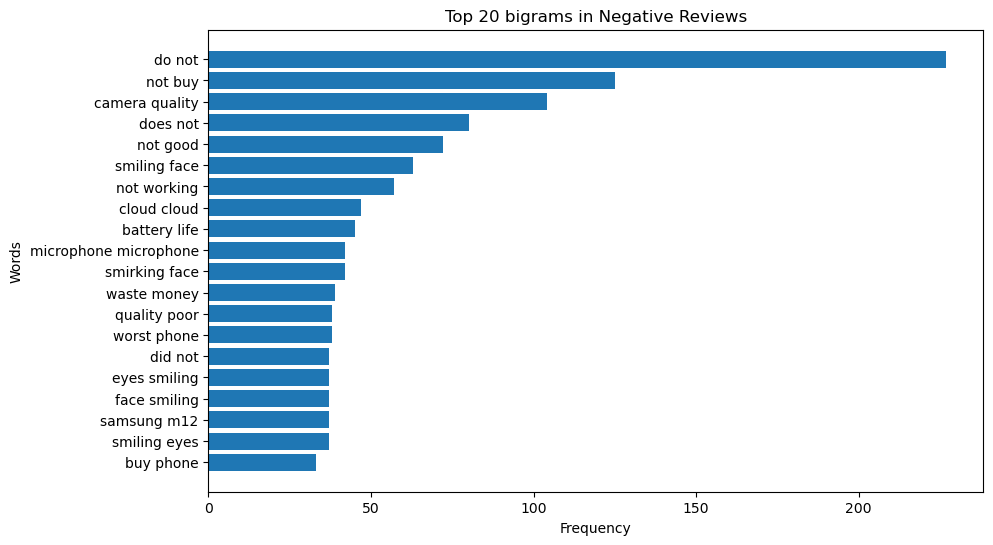

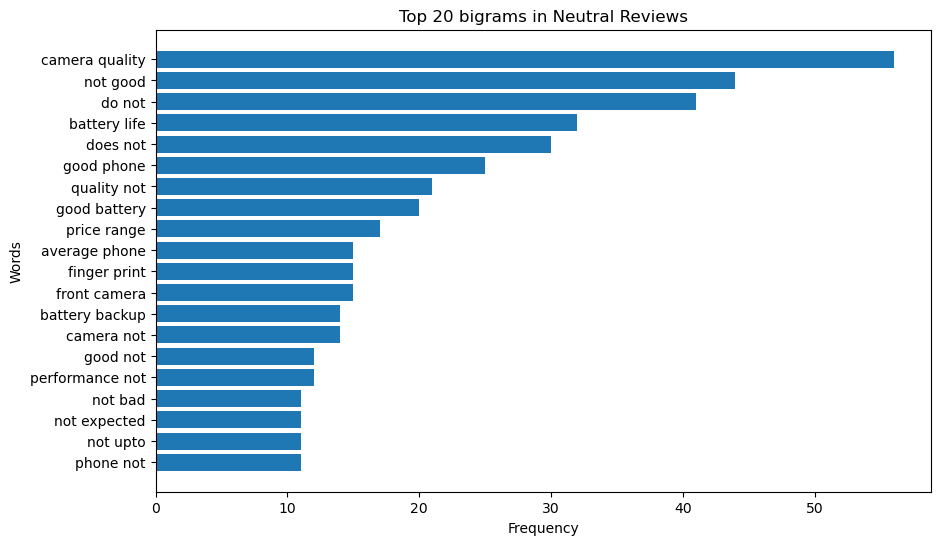

In [19]:
for sentiment in ['positive', 'negative', 'neutral']:

    # Get words and their frequencies
    words = [item[0] for item in top_bigrams[sentiment]]
    counts = [item[1] for item in top_bigrams[sentiment]]

    # Create bar chart
    plt.figure(figsize=(10, 6))

    plt.barh(words, counts)

    plt.title(f'Top 20 bigrams in {sentiment.title()} Reviews')
    plt.xlabel('Frequency')
    plt.ylabel('Words')

    # Show highest frequency at the top
    plt.gca().invert_yaxis()

    plt.show()

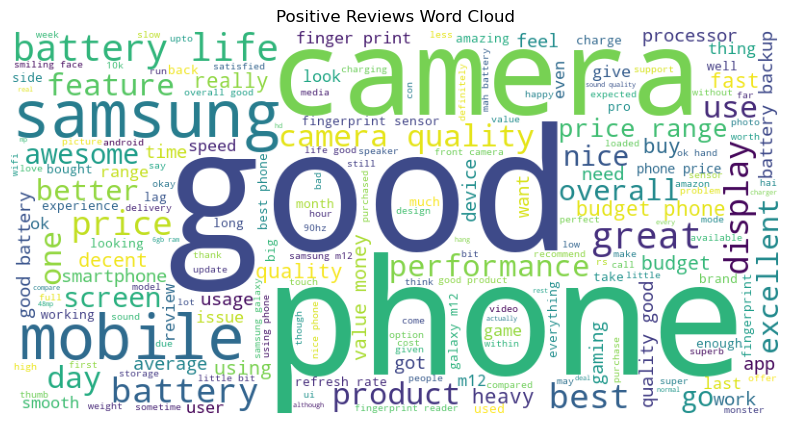

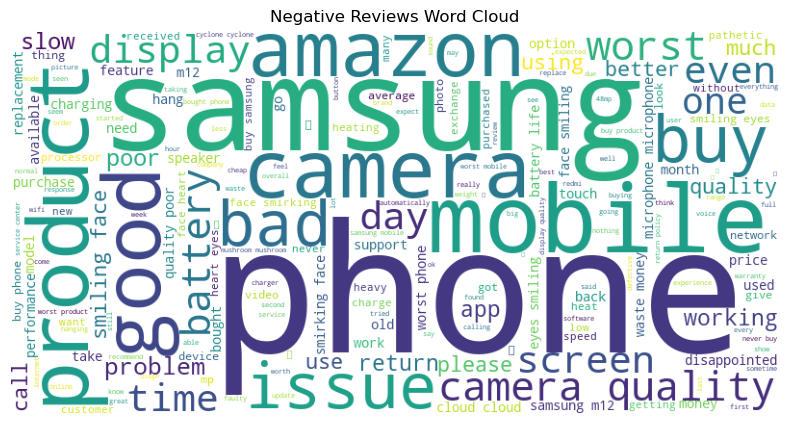

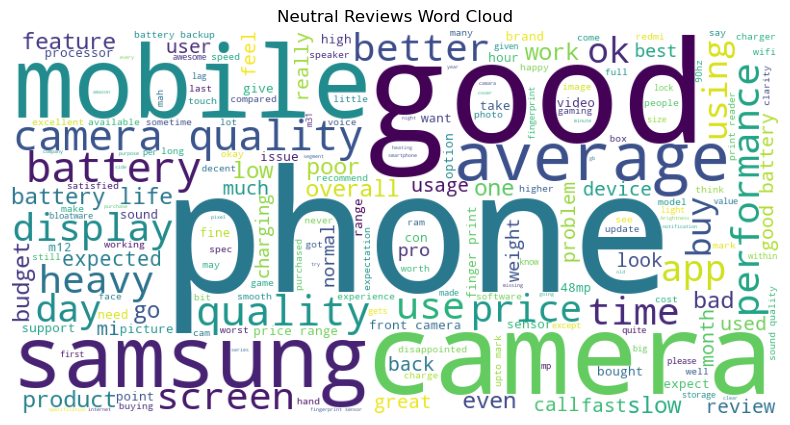

In [20]:
from wordcloud import WordCloud
sentiments = ["positive", "negative", "neutral"]

for sentiment in sentiments:

    # Combine all reviews of one sentiment
    text = " ".join(
        df[df["sentiment"] == sentiment]["clean_review"]
    )

    # Create word cloud
    wordcloud = WordCloud(
        width=800,
        height=400,
        background_color="white"
    ).generate(text)

    # Display word cloud
    plt.figure(figsize=(10, 5))

    plt.imshow(wordcloud)

    plt.title(f"{sentiment.title()} Reviews Word Cloud")

    plt.axis("off")

    plt.show()

Word Cloud analysis was performed separately for positive, negative, and neutral reviews to identify frequently occurring words associated with each sentiment. Larger words represent higher frequency within the respective sentiment category. This visualization provides an intuitive understanding of the vocabulary and common expressions used by customers.

### Validated the cleaned text

In [21]:
# Find all emojis in the full_clean_text column
emojis = [e for review in df['clean_review'] for e in review if emoji.is_emoji(e)]

print(f"Total emojis found: {len(emojis)}")

Total emojis found: 0


In [22]:
df[['body', 'full_review', 'clean_review']].head(10)

,body,full_review,clean_review
0,Very disappointed with the overall performance...,Horrible product Very disappointed with the ov...,horrible product disappointed overall performa...
1,Camera quality is low,Camera quality is not like 48 megapixel Camera...,camera quality not like 48 megapixel camera qu...
2,"Got the mobile on the launch date,Battery must...","Overall Got the mobile on the launch date,Batt...",overall got mobile launch date battery must ap...
3,1. It doesn't work with 5.0GHz WiFi frequency....,A big no from me 1. It doesn't work with 5.0GH...,big no 1 does not work 5 0ghz wifi frequency 2...
4,"Not worth buying....faulty software, poor disp...",Put your money somewhere else Not worth buying...,put money somewhere else not worth buying faul...
5,I will never purchase Samsung phones. Phone is...,Too much lagging and slow I will never purchas...,much lagging slow never purchase samsung phone...
6,This is worst samsung mobile I have seen from ...,Worst samsung mobile ever This is worst samsun...,worst samsung mobile ever worst samsung mobile...
7,मोबाइल का कैमरा बिल्कुल भी सही नही है 48 PM बत...,कैसा दिखाते है उसका 10 % भी नही मोबाइल का कैमर...,कैसा दिखाते है उसका 10 भी नही मोबाइल का कैमरा ...
8,The phone hangs a lot and is very slow. I rece...,Slow performance The phone hangs a lot and is ...,slow performance phone hangs lot slow received...
9,Very poor quality camera .Found box seal damag...,Don’t buy from Amazon. Very poor quality camer...,do not buy amazon poor quality camera found bo...


In [23]:
df[["clean_review"]].isnull().sum()

clean_review    0
dtype: int64

In [24]:
df[["clean_review"]].duplicated().sum()

np.int64(0)

"The EDA was performed to understand the dataset structure, sentiment distribution, review characteristics, and frequently occurring words and phrases. Reviews were analyzed separately across positive, negative, and neutral sentiment categories using review length analysis, unigram frequency analysis, word clouds, and bigram analysis. This helped identify common customer opinions and sentiment-related patterns before moving to model development."

## Machine Learning Model

### TF-IDF / Logistic Regression, Naive Bayes, SVM

__Goal__: building the simplest, fastest sentiment classifier as *baseline*. If a much more complex model barely beats a simple __TF-IDF__ + Logistic Regression that complexity is not worth it in nproduction

__Approach__: convert the text into numeric vectors using __TF_IDF__ (Term Frequency - Inverse Document Frequency), then train three `scikit-learn` classifiers on those vectors: Logisitc Regression, Naive Bayes, and a linear SVM. We compare them and save best one for deployment

In [25]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, classification_report, confusion_matrix, ConfusionMatrixDisplay

In [26]:
df.head()

,title,rating,body,sentiment,full_review,word_count,clean_review
0,Horrible product,1,Very disappointed with the overall performance...,negative,Horrible product Very disappointed with the ov...,10,horrible product disappointed overall performa...
1,Camera quality is not like 48 megapixel,3,Camera quality is low,neutral,Camera quality is not like 48 megapixel Camera...,11,camera quality not like 48 megapixel camera qu...
2,Overall,4,"Got the mobile on the launch date,Battery must...",positive,"Overall Got the mobile on the launch date,Batt...",67,overall got mobile launch date battery must ap...
3,A big no from me,1,1. It doesn't work with 5.0GHz WiFi frequency....,negative,A big no from me 1. It doesn't work with 5.0GH...,72,big no 1 does not work 5 0ghz wifi frequency 2...
4,Put your money somewhere else,1,"Not worth buying....faulty software, poor disp...",negative,Put your money somewhere else Not worth buying...,34,put money somewhere else not worth buying faul...


## Train-Test split

- We split the data before vectorizing, and we use `stratify= y` so the train and test sets both preserve the same class proprtions
- In the EDA we saw roughly 50% positive / 36% negative / 14% neutral
- Without stratification, a random split could put almost all neitral reviews into one side, making evalution unreliable

In [27]:
X= df['clean_review']
y= df['sentiment']

label_map = {'negative': 0, 
             'neutral': 1, 
             'positive': 2}

df['label'] = df['sentiment'].map(label_map)

X_train, X_test, y_train, y_test= train_test_split(X, y, 
                                                   test_size= 0.2, 
                                                   stratify= y, 
                                                   random_state= 14)

print(f"Train size: {len(X_train)} | Test size: {len(X_test)}")
print(f"\nTrain Class balance:\n {(y_train.value_counts() / len(y_train) * 100).map('{:.2f}%'.format)}")

Train size: 1152 | Test size: 288

Train Class balance:
 sentiment
positive    50.61%
negative    35.59%
neutral     13.80%
Name: count, dtype: object


## Vectorize text with TF-IDF

`TfidfVectorizer` converts each review into a vector where every entry
corresponds to a word (or word-pair) in our vocabulary. The value is
high when a word appears often in *this* review but rarely across *all*
reviews — those words are the most distinctive for that specific review.

Key parameters explained:
- `max_features=5000` — keep only the 5000 most informative words/n-grams, to keep the model fast and avoid overfitting to rare words that appear in just one review.
- `ngram_range=(1, 2)` — use both single words ("camera") and two-word phrases ("camera quality"), since phrases often carry sentiment that single words miss (e.g. "not good" vs. "good").
- `min_df=2` — ignore terms that appear in fewer than 2 reviews (too rare to be a reliable signal).

**Important:** we call `.fit_transform()` on the TRAINING data only, then
`.transform()` (no `fit`) on the test data. If we fit on the full
dataset, information from the test set would "leak" into the
vectorizer's vocabulary and IDF weights — inflating our evaluation
scores in a way that wouldn't hold up on truly unseen reviews.


In [28]:
tfidf= TfidfVectorizer(max_features= 5000, 
                       ngram_range= (1, 2), 
                       min_df= 2)

X_train_scaled= tfidf.fit_transform(X_train)    # learns vocabulary + transform training data
X_test_scaled= tfidf.transform(X_test)          # reuses same vocabulary on test data

print(f"TF-IDF Train Shape: {X_train_scaled.shape}")
print(f"TF-IDF Test Shape: {X_test_scaled.shape}")

TF-IDF Train Shape: (1152, 5000)
TF-IDF Test Shape: (288, 5000)


## Train three classic models

We train all three so we can compare them fairly on the same TF-IDF features

- __Logistic Regression__: a strong, well-calibrated linear baseline, usually the best starting point for text classification.
- __Naive Byes__: extremely fast, works well on word-count-style features, classic text classification algorithm
- __Linear SVM__: often very strong on high-dimensional sparse data like TF-IDf vectors

`class_weight= 'balanced'` (Logistic Regression / SVM) automatically gives more weight to minority class (neutral) during training, to partly counter the class imbalance we found in the EDA

In [29]:
# create a evaluation function to evaluate all models 
def evaluate_model(y_true, y_pred):
    accuracy= accuracy_score(y_true, y_pred)

    precision, recall, f1, _= precision_recall_fscore_support(y_true, 
                                                              y_pred,
                                                              average= 'macro',
                                                              zero_division= 0)
    return{
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1_Macro': f1
    }

In [30]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, class_weight='balanced', random_state=14),
    'Naive Bayes': MultinomialNB(),
    'Linear SVM': LinearSVC(max_iter=5000, class_weight='balanced', random_state=14)
}

ml_results = {}

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_test_pred = model.predict(X_test_scaled)
    
    # Save the returned dictionary to a variable
    metrics = evaluate_model(y_test, y_test_pred)
    
    # Store the combined dictionary in results
    ml_results[name] = metrics
    
    # Print using the values from the dictionary
    print(f"{name:25s} Accuracy: {metrics['Accuracy']:.2f} Precision: {metrics['Precision']:.2f} Recall: {metrics['Recall']:.2f} Macro-f1: {metrics['F1_Macro']:.2f}")

Logistic Regression       Accuracy: 0.80 Precision: 0.71 Recall: 0.70 Macro-f1: 0.70
Naive Bayes               Accuracy: 0.78 Precision: 0.54 Recall: 0.60 Macro-f1: 0.56
Linear SVM                Accuracy: 0.82 Precision: 0.73 Recall: 0.69 Macro-f1: 0.69


### Comparing the Models

In [31]:
ml_comp_df= pd.DataFrame(ml_results).T
ml_comp_df.round(3)

,Accuracy,Precision,Recall,F1_Macro
Logistic Regression,0.799,0.709,0.700,0.701
Naive Bayes,0.785,0.542,0.600,0.565
Linear SVM,0.816,0.732,0.688,0.692


## Pick the Best Model
We select the model with highest __macro-f1__ not just accuracy for the class imbalance reason

In [32]:
# 1. Dynamically select the model with the highest Macro-F1
best_model_name = max(ml_results, key=lambda x: ml_results[x]['F1_Macro'])
best_ml_model = models[best_model_name]

print(f"Best Model: {best_model_name} (Macro-F1: {ml_results[best_model_name]['F1_Macro']:.3f})\n")

# 2. Generate predictions on test data
y_best_ml_pred = best_ml_model.predict(X_test_scaled)

# 3. Print classification report
print(classification_report(y_test, y_best_ml_pred))

# storing for future use
lr_model= best_ml_model

Best Model: Logistic Regression (Macro-F1: 0.701)

              precision    recall  f1-score   support

    negative       0.81      0.90      0.85       102
     neutral       0.45      0.35      0.39        40
    positive       0.87      0.85      0.86       146

    accuracy                           0.80       288
   macro avg       0.71      0.70      0.70       288
weighted avg       0.79      0.80      0.79       288



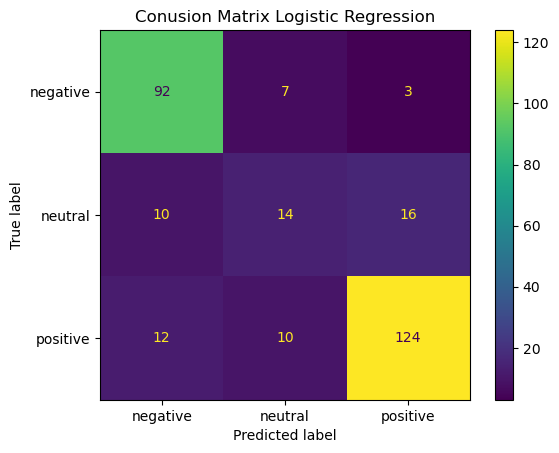

In [33]:
cm= confusion_matrix(y_test, y_best_ml_pred)
disp= ConfusionMatrixDisplay(confusion_matrix= cm,
                             display_labels= ['negative', 'neutral', 'positive'])
disp.plot()
plt.title('Conusion Matrix Logistic Regression')
plt.show()

**Reading the confusion matrix:** the diagonal cells are correct
predictions. Off-diagonal cells show where the model gets confused —
typically "neutral" reviews are the hardest to classify correctly,
because 3-star reviews often contain a mix of positive and negative
language (e.g. "Good battery but average camera"), which is genuinely
ambiguous even for a human reader.

## Try it on a custom review

A quick sanity check with a brand-new sentence, run through the exact
same pipeline (clean -> TF-IDF -> predict) that the deployed app will use.


In [34]:
def predict_ml(text: str) -> str:
    cleaned = clean_text(text)
    vec = tfidf.transform([cleaned])
    model_obj = lr_model
    prediction = model_obj.predict(vec)[0]
    
    # Translate the integer back to a string label
    label_map = {0: 'negative', 1: 'neutral', 2: 'positive'}
    
    # .get() returns the string if it's a number, or just the original prediction if you ever retrain on strings
    return label_map.get(prediction, prediction)

sample_reviews = [
    "Battery life is amazing and the camera is decent for this price.",
    "Worst phone ever, camera quality is pathetic and it heats up constantly.",
    "It's okay, does the job but nothing special.",
]

for review in sample_reviews:
    print(f"{predict_ml(review):>10}  <-  {review}")

  positive  <-  Battery life is amazing and the camera is decent for this price.
  negative  <-  Worst phone ever, camera quality is pathetic and it heats up constantly.
  negative  <-  It's okay, does the job but nothing special.


## Conclusion — ML Baseline

- We built a TF-IDF (unigram + bigram) representation of the cleaned review text and trained three classic classifiers: Logistic Regression, Multinomial Naive Bayes, and Linear SVM.
- We evaluated models with **macro-F1** (not just accuracy) because the dataset is imbalanced — this gives the minority "neutral" class equal importance in scoring.
- The best-performing model and the fitted TF-IDF vectorizer are saved to `models/` for reuse in the Streamlit app.
- This baseline is our **reference point**: it's fast to train, easy to interpret (we can literally see which words drive each prediction), and gives a strong first estimate of how separable the classes are.
- Any deep learning or transformer-based model we build next should meaningfully outperform this baseline to justify its extra complexity, training time, and compute cost.

# __Deep Learning Model__

Deep Learning roadmap

We'll do this in this order:

1. **Prepare text for neural networks**
- Tokenization
- Vocabulary
- Integer sequences
- Padding

2. __Word Embedding__
- Convert words into dense numerical vectors

3. __Simple RNN__
- Build
- Train
- Evaluate

4. __LSTM__
- Build
- Train
- Evaluate

5. __Compare RNN vs LSTM__

-------------------------------------------------------------------------------------------------
        Review
           ↓
        Cleaning
           ↓
        Tokenization
           ↓
        Integer sequences
           ↓
        Padding
           ↓
       Embedding
           ↓
        RNN / LSTM
           ↓
        Sentiment

In [35]:
df.columns

Index(['title', 'rating', 'body', 'sentiment', 'full_review', 'word_count',
       'clean_review', 'label'],
      dtype='object')

In [36]:
df[['clean_review', 'sentiment']].head()

,clean_review,sentiment
0,horrible product disappointed overall performa...,negative
1,camera quality not like 48 megapixel camera qu...,neutral
2,overall got mobile launch date battery must ap...,positive
3,big no 1 does not work 5 0ghz wifi frequency 2...,negative
4,put money somewhere else not worth buying faul...,negative


In [37]:
# import tensorflow
import tensorflow as tf                                             # dl frame work
from tensorflow.keras.preprocessing.text import Tokenizer           # converts text into numbers
from tensorflow.keras.preprocessing.sequence import pad_sequences   # makes all reviews same length (pads with 0)

# Create X and y
X= df['clean_review']
y= df['sentiment']

# convert sentiment labels in numbers
label_map= {
    'negative': 0,
    'neutral': 1,
    'positive': 2
}

y= y.map(label_map)      # because neural network works with numerical target values

y.value_counts()

sentiment
2    729
0    512
1    199
Name: count, dtype: int64

### Train/test split

We should split before fitting the tokenizer, so information from the test set doesn't influence vocabulary construction

In [38]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test= train_test_split(X, y, 
                                                   test_size= 0.2, 
                                                   random_state= 14, 
                                                   stratify= y)

### Tokenization
Now create the tokenizer

In [39]:
tokenizer= Tokenizer(num_words= 10000,     # we will keep up to the most frequent 10,000 words
                     oov_token= '<OOV>')   # Out of vocabulary 
                                           # If any word isn't in the vocabulary, it can be represented by the OOV token instead of causing an error.

# fit it only on training text
tokenizer.fit_on_texts(X_train)

# convert text into sequences
X_train_seq= tokenizer.texts_to_sequences(X_train)
X_test_seq= tokenizer.texts_to_sequences(X_test)

### Padding
Make all reviews to same length

In [40]:
# first check the reviews length
lengths= [len(seq) for seq in X_train_seq]

print(f"Maximum length: {max(lengths)}")
print(f"Avarage length: {np.mean(lengths).round(2)}")
print(f'Median length: {np.median(lengths).round(3)}')
print(f'90th percentile: {np.percentile(lengths, 90).round(3)}')
print(f'95th percentile: {np.percentile(lengths, 95).round(3)}')
print(f'99th percentile: {np.percentile(lengths, 99.666).round(3)}')

Maximum length: 624
Avarage length: 38.26
Median length: 31.0
90th percentile: 63.9
95th percentile: 82.45
99th percentile: 200.491


In [41]:
MAX_LEN= 200
X_train_pad= pad_sequences(X_train_seq, 
                           maxlen= MAX_LEN,
                           padding= 'post',
                           truncating= 'post')

X_test_pad= pad_sequences(X_test_seq,
                         maxlen= MAX_LEN,
                         padding= 'post',
                         truncating= 'post')

In [42]:
X_train_pad[0]

array([   3,   10, 1764, 2451,    2,  155, 2452,   54,   16,  750, 2453,
         95,  277, 2454,  818,   81,  346, 2455, 2456,   10,   71,   46,
        101,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,   

In [43]:
X_test_pad[0]

array([ 388, 2306,   41,    3,   24,  288,    5,    8,   71,   18, 1227,
          8,    6,   14,   72,   75, 1372,  339,    1,  135,  111,   53,
        339, 1177,   38,    1, 5248,   75,    6,  657,  312,   42,  136,
         45,    6, 2232,  212,   44,  102,   38,   24,   18, 2287,   32,
         10,  214,   83, 4043,  634,   26, 3194,   41, 2501,  318,   72,
         11,    7,   17,  979,  263, 4145,  217,   18, 1227,  527, 1574,
          1,   72,    3,   47,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,   

### Word Embedding
Converts each word ID into a dense vector

In [44]:
# first we need to know how many words our tokenizer learned.
# count the vocabulary size
vocab_size= min(10000, 
                len(tokenizer.word_index) + 1)

print('Vocabulary size:', vocab_size)

# choose embedding dimension
embedding_dim= 128           # This means each word will be represented by a vector containing 128 numbers.

Vocabulary size: 5447


### Calculate and Apply Class Weights
To overcome class collapse in deep learning models

In [45]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

# Calculate class weights based on the training labels
weights = compute_class_weight(class_weight='balanced', 
                               classes=np.unique(y_train), 
                               y=y_train)

# Convert to a dictionary for Keras
class_weight_dict = dict(enumerate(weights))

print("Class Weights:", class_weight_dict)

Class Weights: {0: np.float64(0.9365853658536586), 1: np.float64(2.4150943396226414), 2: np.float64(0.6586620926243568)}


### Build our first RNN model

In [46]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Embedding, SimpleRNN, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

tf.keras.utils.set_random_seed(14)

# Build the model
model_rnn = Sequential([
    Input(shape=(MAX_LEN,)),
    Embedding(input_dim=vocab_size, output_dim=embedding_dim, mask_zero=True),  # ignore padding
    SimpleRNN(64),
    Dropout(0.3),
    Dense(3, activation='softmax')
])

# Compile the model
model_rnn.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])

model_rnn.summary()

# Stop early if validation loss stops improving
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

# Train the model
history_rnn = model_rnn.fit(X_train_pad, y_train,
                            validation_split=0.2,
                            epochs=20,
                            batch_size=32,
                            class_weight=class_weight_dict,   # apply the class weights
                            callbacks=[early_stop])

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding (Embedding)                │ (None, 200, 128)            │         697,216 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ simple_rnn (SimpleRNN)               │ (None, 64)                  │          12,352 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 3)                   │             195 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 709,763 (2.71 MB)

 Trainable params: 709,763 (2.71 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 6s 93ms/step - accuracy: 0.5570 - loss: 1.0296 - val_accuracy: 0.6450 - val_loss: 0.8500
Epoch 2/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 2s 67ms/step - accuracy: 0.7557 - loss: 0.7925 - val_accuracy: 0.4372 - val_loss: 1.0554
Epoch 3/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 2s 67ms/step - accuracy: 0.9240 - loss: 0.4532 - val_accuracy: 0.5541 - val_loss: 0.9451
Epoch 4/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 2s 70ms/step - accuracy: 0.9902 - loss: 0.1560 - val_accuracy: 0.7013 - val_loss: 0.7845
Epoch 5/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 2s 67ms/step - accuracy: 0.9989 - loss: 0.0633 - val_accuracy: 0.7229 - val_loss: 0.7423
Epoch 6/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 2s 69ms/step - accuracy: 1.0000 - loss: 0.0372 - val_accuracy: 0.7056 - val_loss: 0.7801
Epoch 7/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 2s 68ms/step - accuracy: 0.9946 - loss: 0.0385 - val_accuracy: 0.7403 - val_loss: 0.7862
Epoch 8/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 2s 68ms/step - accuracy: 0.9262 - loss: 0.2243 - val_accuracy: 0.4935 - v

### Visulize the training curves

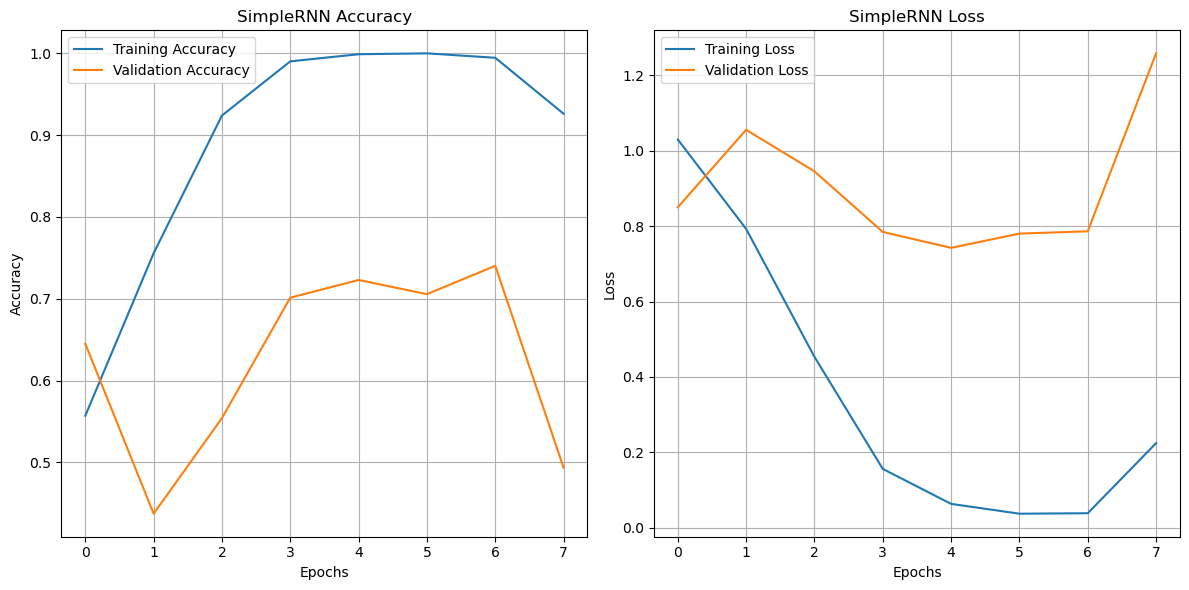

In [47]:
plt.figure(figsize= (12, 6))

# accuracy
plt.subplot(1, 2, 1)
plt.plot(history_rnn.history['accuracy'], label= 'Training Accuracy')
plt.plot(history_rnn.history['val_accuracy'], label= 'Validation Accuracy')
plt.legend()
plt.grid(True)
plt.title('SimpleRNN Accuracy')
plt.xlabel("Epochs")
plt.ylabel('Accuracy')

# Loss
plt.subplot(1, 2, 2)
plt.plot(history_rnn.history['loss'], label= 'Training Loss')
plt.plot(history_rnn.history['val_loss'], label= 'Validation Loss')
plt.title('SimpleRNN Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

### Evaluation

In [48]:
# test set evaluation
test_loss_rnn, test_accuracy_rnn= model_rnn.evaluate(X_test_pad,
                                             y_test)

print(f"\nTest Accuracy: {test_accuracy_rnn*100:.2f}%")
print(f"Test Loss: {test_loss_rnn:.4f}\n")

# predictions
y_pred_prob= model_rnn.predict(X_test_pad)           # probabilities for negative, neutral, positive

y_pred_rnn= y_pred_prob.argmax(axis= 1)                  # selects the class with the highest probability

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.7188 - loss: 0.7344

Test Accuracy: 71.88%
Test Loss: 0.7344

9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step


### Classification Report

In [49]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred_rnn, target_names= ['negative', 'neutral', 'positive']))

              precision    recall  f1-score   support

    negative       0.74      0.78      0.76       102
     neutral       0.21      0.20      0.21        40
    positive       0.84      0.82      0.83       146

    accuracy                           0.72       288
   macro avg       0.60      0.60      0.60       288
weighted avg       0.72      0.72      0.72       288



### Confusion matrix

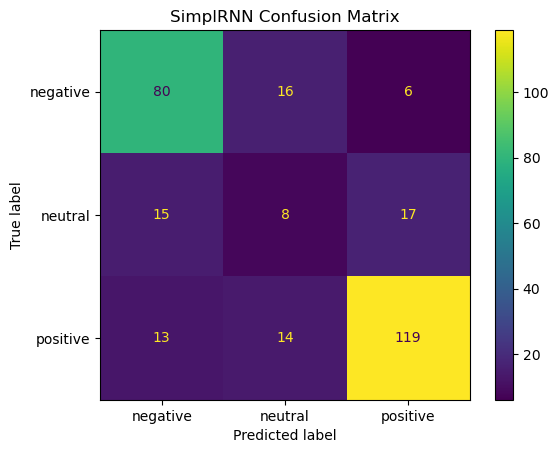

In [50]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm= confusion_matrix(y_test, y_pred_rnn)

disp= ConfusionMatrixDisplay(confusion_matrix= cm,
                             display_labels= ['negative', 'neutral', 'positive'])
disp.plot()
plt.title('SimplRNN Confusion Matrix')
plt.show()

### LSTM Model

In [51]:
from tensorflow.keras.layers import LSTM
tf.keras.utils.set_random_seed(14)

# build the model
model_lstm= Sequential([Input(shape= (MAX_LEN,)),
                       Embedding(input_dim= vocab_size, output_dim= embedding_dim, mask_zero= True),
                       LSTM(64),         
                       Dense(3, activation= 'softmax')])

# compile the model
model_lstm.compile(optimizer= 'adam',
                   loss= 'sparse_categorical_crossentropy',
                   metrics= ['accuracy'])

# check the architecture
model_lstm.summary()

# Stop early if validation loss stops improving
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

# train the model
history_lstm= model_lstm.fit(X_train_pad,
                             y_train,
                             validation_split= 0.2,
                             epochs= 15,
                             batch_size= 32,
                             class_weight=class_weight_dict,   # apply the class weights
                             callbacks=[early_stop])

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)              │ (None, 200, 128)            │         697,216 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm (LSTM)                          │ (None, 64)                  │          49,408 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 3)                   │             195 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 746,819 (2.85 MB)

 Trainable params: 746,819 (2.85 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/15
29/29 ━━━━━━━━━━━━━━━━━━━━ 8s 152ms/step - accuracy: 0.5125 - loss: 1.0656 - val_accuracy: 0.7446 - val_loss: 0.8211
Epoch 2/15
29/29 ━━━━━━━━━━━━━━━━━━━━ 4s 128ms/step - accuracy: 0.8111 - loss: 0.7500 - val_accuracy: 0.7619 - val_loss: 0.7351
Epoch 3/15
29/29 ━━━━━━━━━━━━━━━━━━━━ 4s 123ms/step - accuracy: 0.8860 - loss: 0.5734 - val_accuracy: 0.7619 - val_loss: 0.7173
Epoch 4/15
29/29 ━━━━━━━━━━━━━━━━━━━━ 4s 126ms/step - accuracy: 0.9490 - loss: 0.3212 - val_accuracy: 0.7056 - val_loss: 0.7379
Epoch 5/15
29/29 ━━━━━━━━━━━━━━━━━━━━ 4s 129ms/step - accuracy: 0.9750 - loss: 0.1236 - val_accuracy: 0.6623 - val_loss: 0.8514
Epoch 6/15
29/29 ━━━━━━━━━━━━━━━━━━━━ 4s 133ms/step - accuracy: 0.9718 - loss: 0.1088 - val_accuracy: 0.6926 - val_loss: 0.9897


### Visualizing the accuracy and loss

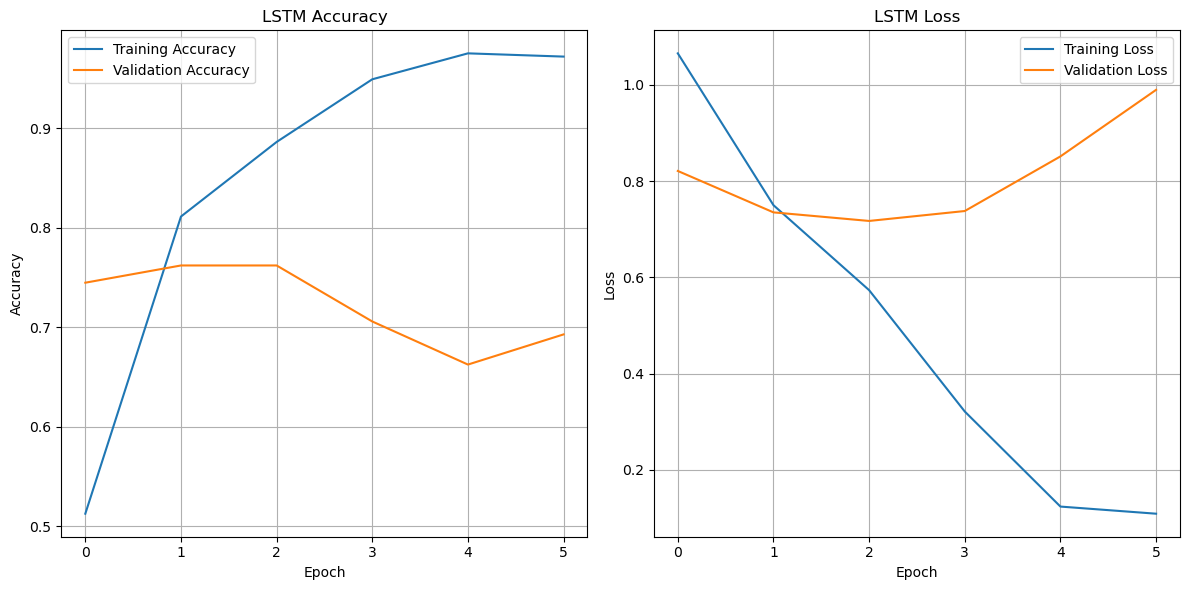

In [52]:
plt.figure(figsize= (12, 6))
plt.subplot(1, 2, 1)
plt.plot(history_lstm.history['accuracy'], label= 'Training Accuracy')
plt.plot(history_lstm.history['val_accuracy'], label= 'Validation Accuracy')
plt.title('LSTM Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.grid(True)
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_lstm.history['loss'], label= 'Training Loss')
plt.plot(history_lstm.history['val_loss'], label= 'Validation Loss')
plt.title('LSTM Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

### Evaluate the model

In [53]:
test_loss_lstm, test_accuracy_lstm= model_lstm.evaluate(X_test_pad, 
                                                        y_test)
print(f"\nTest Loss: {test_loss_lstm:.4f}")
print(f"Test Accuracy: {test_accuracy_lstm*100:.2f}%\n")

# prediction
y_pred_proba= model_lstm.predict(X_test_pad)
y_pred_lstm= y_pred_proba.argmax(axis= 1)

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.7674 - loss: 0.6540

Test Loss: 0.6540
Test Accuracy: 76.74%

9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step


### Classification report

In [54]:
print(classification_report(y_test, y_pred_lstm, target_names= ['negative', 'neutral', 'positive']))

              precision    recall  f1-score   support

    negative       0.86      0.86      0.86       102
     neutral       0.29      0.28      0.28        40
    positive       0.82      0.84      0.83       146

    accuracy                           0.77       288
   macro avg       0.66      0.66      0.66       288
weighted avg       0.76      0.77      0.77       288



### Confusion Matrix

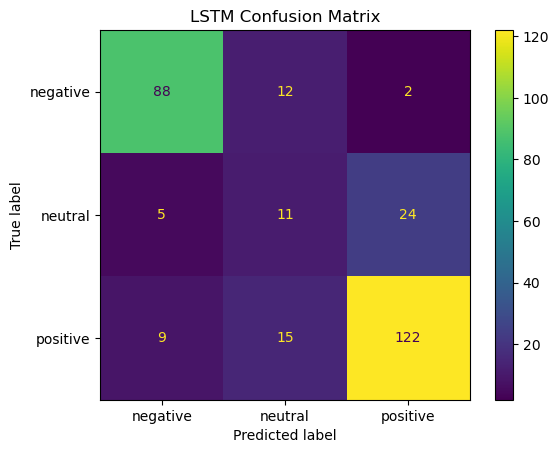

In [55]:
cm= confusion_matrix(y_test, y_pred_lstm)
disp= ConfusionMatrixDisplay(confusion_matrix= cm,
                             display_labels= ['negative', 'neutral', 'positive'])
disp.plot()
plt.title('LSTM Confusion Matrix')
plt.show()

In [56]:
dl_results= {}

metrics_rnn= evaluate_model(y_test, y_pred_rnn)
dl_results['Simple RNN']= metrics_rnn

metrics_lstm= evaluate_model(y_test, y_pred_lstm)
dl_results['LSTM']= metrics_lstm

dl_comp_df= pd.DataFrame(dl_results).T

dl_comp_df

,Accuracy,Precision,Recall,F1_Macro
Simple RNN,0.718750,0.596432,0.599794,0.597807
LSTM,0.767361,0.658848,0.657787,0.658243


### Deep Learning Conclusion

| Model | Accuracy | Precision (macro) | Recall (macro) | F1 (macro) |
|---|---|---|---|---|
| Simple RNN | 71.88% | 59.64% | 59.98% | 59.78% |
| LSTM | 76.74% | 65.88% | 65.78% | 65.82% |

**What changed.** The first RNN and LSTM predicted "positive" for almost every review (macro-F1 about 0.22). After four fixes, both now learn all three classes:
- masking the padded zeros (`mask_zero=True`)
- applying the class weights during training
- adding dropout
- using early stopping

**Findings**
1. **LSTM beats the Simple RNN** on every metric (macro-F1 0.658 vs 0.598, accuracy 76.7% vs 71.9%). Its gated memory handles longer reviews better than a plain RNN.
2. **Negative and positive are learned well.** LSTM F1 is about 0.86 for negative and 0.83 for positive. The RNN scores 0.76 and 0.83.
3. **Neutral is still the weak point.** Only 8 of 40 neutral reviews are found by the RNN (recall 20%) and 11 of 40 by the LSTM (recall 27.5%). Most missed neutral reviews are predicted as positive (LSTM: 24 of 40), which fits the fact that 3-star reviews often include praise.
4. **Neither network beats the classical baseline.** With only 1,440 reviews, the LSTM's macro-F1 (0.658) is below TF-IDF + Logistic Regression (0.701). Deep models need more data to show their strength.

## Transformer
For the Transformer stage, we'll use __Hugging Face Transformers__ and fine-tune a pretrained __DistilBERT__ model for our three sentiment classes.

In [57]:
# install required packages
import transformers
import torch

print('Transformers:', transformers.__version__)
print('PyTorch:', torch.__version__)

Transformers: 5.18.0
PyTorch: 2.14.1+cpu


In [58]:
df.columns

Index(['title', 'rating', 'body', 'sentiment', 'full_review', 'word_count',
       'clean_review', 'label'],
      dtype='object')

In [59]:
# prepare the labels
X= df['clean_review']
y= df['sentiment']

label_map= {
    'negative': 0,
    'neutral': 1,
    'positive': 2
}

y_bert= y.map(label_map)
y_bert.value_counts()

sentiment
2    729
0    512
1    199
Name: count, dtype: int64

In [60]:
# split the data into train and test sets
X_train_bert, X_test_bert, y_train_bert, y_test_bert= train_test_split(X, y_bert,
                                                                       test_size= 0.2,
                                                                       stratify= y_bert,
                                                                       random_state= 14)

X_train_bert, X_val_bert, y_train_bert, y_val_bert = train_test_split(X_train_bert,
                                                                      y_train_bert,
                                                                      test_size=0.1,
                                                                      stratify=y_train_bert,
                                                                      random_state=14)

print("Training samples:", len(X_train_bert))
print("Test samples:", len(X_test_bert))
print("Validation samples:", len(X_val_bert))
print("Validation Labels:", len(y_val_bert))

Training samples: 1036
Test samples: 288
Validation samples: 116
Validation Labels: 116


### Load the DistilBERT tokenizer

In [61]:
from transformers import AutoTokenizer                                      # It converts text into the representation expected by DistilBERT

tokenizer_bert= AutoTokenizer.from_pretrained('distilbert-base-uncased')    # DistilBERT → smaller/faster version of BERT.
                                                                            # base → standard pretrained architecture.
                                                                            # uncased → doesn't distinguish between uppercase and lowercase words.

# Tokenize the reviews for DistilBERT
train_encodings= tokenizer_bert(X_train_bert.tolist(),
                                max_length= 200,
                                truncation= True,
                                padding= True)

val_encodings = tokenizer_bert(X_val_bert.tolist(),
                               max_length=200,
                               truncation=True,
                               padding=True)

test_encodings= tokenizer_bert(X_test_bert.tolist(),
                              max_length= 200,
                              truncation= True,
                              padding= True)

# Inspecting one review before building the model
print(f"Original Review:" f"\n {X_train_bert.iloc[0]}")

print(f"\nToken IDs: {train_encodings['input_ids'][0]}")               # token numbers

print(f"\nAttention Mask: {train_encodings['attention_mask'][0]}")     # tells model which positions are real tokens

Original Review:
 best range used week detailed reviewpros1 good battery life3 fast processing4 nice sound5 good fingerprint scannerscons 1 average display video quality sucks 2 big hand3 screen soft break 2 3 fall4 average camera go m21 2021 edition better camera m12 quad camera no use

Token IDs: [101, 2190, 2846, 2109, 2733, 6851, 3319, 21572, 2015, 2487, 2204, 6046, 2166, 2509, 3435, 6364, 2549, 3835, 2614, 2629, 2204, 4344, 16550, 26221, 9363, 3619, 1015, 2779, 4653, 2678, 3737, 19237, 1016, 2502, 2192, 2509, 3898, 3730, 3338, 1016, 1017, 2991, 2549, 2779, 4950, 2175, 25525, 2487, 25682, 3179, 2488, 4950, 23290, 2475, 17718, 4950, 2053, 2224, 102, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 

### Create a Dataset for DistilBERT
The tokenizer has produced dictionaries, but the model needs the data in a proper dataset format.

We'll create a PyTorch Dataset.

In [62]:
import torch                                             # We import PyTorch because DistilBERT will be fine-tuned using PyTorch.

class ReviewDataset(torch.utils.data.Dataset):           # class inherits from 
    def __init__(self, encodings, labels):               # tells pytorch to how to get a particular sample and how mannhy samples are present
        self.encodings= encodings
        self.labels= labels

    def __getitem__(self, idx):                          # idx --> index
        item= {
            key: torch.tensor(val[idx])                  # gets the token IDs and converts that token IDs into a PyTorch tensor.
            for key, val in self.encodings.items()
        }

        item['labels']= torch.tensor(self.labels[idx])   # adding the sentiment label

        return item

    def __len__(self):                                  # this tells pytorch how many reviews are in this dataset
        return len(self.labels)

In [63]:
# create train, val, and test datasets
train_dataset= ReviewDataset(train_encodings, y_train_bert.tolist())
val_dataset= ReviewDataset(val_encodings, y_val_bert.tolist())
test_dataset= ReviewDataset(test_encodings, y_test_bert.tolist())

# check 
print("Original X:", len(X))
print("Original y:", len(y_bert))

print("Train:", len(X_train_bert))
print("Validation:", len(X_val_bert))
print("Test:", len(X_test_bert))

Original X: 1440
Original y: 1440
Train: 1036
Validation: 116
Test: 288


### Load the pre-trained DistilBERT model
We don't train DistilBERT from zero.

We take an already pre-trained DistilBERT and fine-tune it for our sentiment classification task.

In [64]:
from transformers import AutoModelForSequenceClassification  # This imports a Hugging Face model class designed specifically for classification tasks.
import transformers
transformers.logging.set_verbosity_error()

model= AutoModelForSequenceClassification.from_pretrained('distilbert-base-uncased',
                                                          num_labels= 3)


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

### Create the evaluation metrics
We want to know how well the model performs.

In [65]:
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

# Hugging Face Trainer calls this function automatically when it evaluates our model.
def compute_metrics(eval_pred):   # eval_pred contains --> model predictons and actual labels

    logits, labels = eval_pred    # separate predictions and actual labels

    predictions = logits.argmax(axis=-1)    # This finds the position of the largest logit

    precision, recall, f1, _ = precision_recall_fscore_support(
        labels,
        predictions,
        average="weighted"   # our classes are not equally distributed, weighted calculates each class's metric and then gives more weight to classes with more samples.
    )

    accuracy = accuracy_score(labels, predictions)

    return {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1
    }

### Set training parameters

We'll use Hugging Face's TrainingArguments.

In [66]:
from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir="./distilbert_results",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,      
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=2,
    weight_decay=0.01,
    load_best_model_at_end=True
)

| Parameter                     | Meaning                               |
| ----------------------------- | ------------------------------------- |
| `learning_rate=2e-5`          | How quickly the model learns          |
| `batch_size=8`               | Reviews processed at once             |
| `epochs=2`                    | Complete passes through training data |
| `weight_decay=0.01`           | Helps reduce overfitting              |
| `eval_strategy="epoch"`       | Evaluate after each epoch             |
| `load_best_model_at_end=True` | Keep the best-performing model        |


### Create the Trainer

Now we connect:

model + datasets + training settings + metrics

In [67]:
from transformers import Trainer

trainer= Trainer(model= model,
                 args= training_args,
                 train_dataset= train_dataset,
                 eval_dataset= val_dataset,
                 compute_metrics= compute_metrics)
print(trainer)
print("Training samples:", len(trainer.train_dataset))
print("Validation samples:", len(trainer.eval_dataset))

Training samples: 1036
Validation samples: 116


### Start DistilBERT fine-tuning

In [68]:
trainer.train()

{'eval_loss': '0.6077', 'eval_accuracy': '0.7672', 'eval_precision': '0.6839', 'eval_recall': '0.7672', 'eval_f1': '0.7152', 'eval_runtime': '20.15', 'eval_samples_per_second': '5.756', 'eval_steps_per_second': '0.744', 'epoch': '1'}


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

{'eval_loss': '0.5135', 'eval_accuracy': '0.7931', 'eval_precision': '0.7037', 'eval_recall': '0.7931', 'eval_f1': '0.7435', 'eval_runtime': '19.55', 'eval_samples_per_second': '5.933', 'eval_steps_per_second': '0.767', 'epoch': '2'}


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

{'train_runtime': '1595', 'train_samples_per_second': '1.299', 'train_steps_per_second': '0.163', 'train_loss': '0.6063', 'epoch': '2'}


TrainOutput(global_step=260, training_loss=0.6063331017127404, metrics={'train_runtime': 1595.2136, 'train_samples_per_second': 1.299, 'train_steps_per_second': 0.163, 'train_loss': 0.6063331017127404, 'epoch': 2.0})

In [69]:
eval_results= trainer.evaluate()
print(eval_results)

{'eval_loss': '0.5135', 'eval_accuracy': '0.7931', 'eval_precision': '0.7037', 'eval_recall': '0.7931', 'eval_f1': '0.7435', 'eval_runtime': '19.86', 'eval_samples_per_second': '5.842', 'eval_steps_per_second': '0.755', 'epoch': '2'}
{'eval_loss': 0.5135361552238464, 'eval_accuracy': 0.7931034482758621, 'eval_precision': 0.703670125963928, 'eval_recall': 0.7931034482758621, 'eval_f1': 0.7435253118121791, 'eval_runtime': 19.855, 'eval_samples_per_second': 5.842, 'eval_steps_per_second': 0.755, 'epoch': 2.0}


In [70]:
test_results= trainer.evaluate(test_dataset)
print(test_results)

{'eval_loss': '0.5499', 'eval_accuracy': '0.7986', 'eval_precision': '0.752', 'eval_recall': '0.7986', 'eval_f1': '0.7597', 'eval_runtime': '48.78', 'eval_samples_per_second': '5.904', 'eval_steps_per_second': '0.738', 'epoch': '2'}
{'eval_loss': 0.549854576587677, 'eval_accuracy': 0.7986111111111112, 'eval_precision': 0.751959517657192, 'eval_recall': 0.7986111111111112, 'eval_f1': 0.7597345141988, 'eval_runtime': 48.7839, 'eval_samples_per_second': 5.904, 'eval_steps_per_second': 0.738, 'epoch': 2.0}


### Classification report + confusion matrix

In [71]:
predictions= trainer.predict(test_dataset)

y_pred_bert= predictions.predictions.argmax(axis= 1)

# actual labels
y_true_bert= predictions.label_ids

print('Classification Report:\n',classification_report(y_true_bert, y_pred_bert,
                            target_names=['negative', 'neutral', 'positive'],
                            digits=4))

Classification Report:
               precision    recall  f1-score   support

    negative     0.7519    0.9510    0.8398       102
     neutral     0.3333    0.0750    0.1224        40
    positive     0.8667    0.8904    0.8784       146

    accuracy                         0.7986       288
   macro avg     0.6506    0.6388    0.6136       288
weighted avg     0.7520    0.7986    0.7597       288



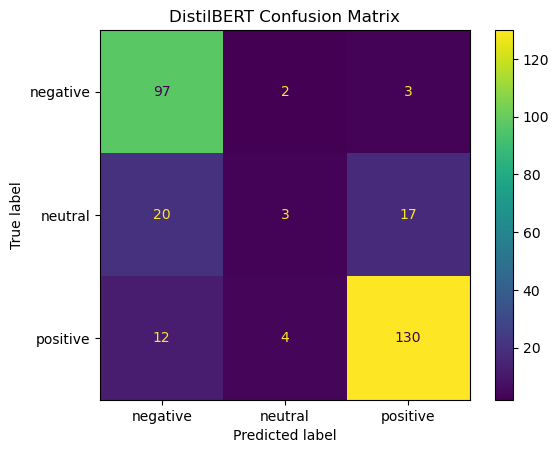

In [72]:
cm= confusion_matrix(y_true_bert, y_pred_bert)
disp_2= ConfusionMatrixDisplay(confusion_matrix= cm, 
                               display_labels= ['negative', 'neutral', 'positive'])
disp_2.plot()
plt.title('DistilBERT Confusion Matrix')
plt.show()

In [73]:
# create a dict to store results
bert_results= {}

# evalute the models
bert_eval= evaluate_model(y_true_bert, y_pred_bert)
bert_results['DistilBERT']= bert_eval

# convert into dataframe
bert_comp_df= pd.DataFrame(bert_results).T
bert_comp_df

,Accuracy,Precision,Recall,F1_Macro
DistilBERT,0.798611,0.650646,0.638797,0.613551


### Predict sentiment for a new review

In [74]:
# create a function
def predict_sen(text):

    # apply the cleaning used during the training
    cleaned_text= clean_text(text)
    
    # tokenize the new review
    inputs= tokenizer_bert(cleaned_text,
                           return_tensors= 'pt',   # pytorch tensor
                           truncation= True,
                           padding= True,
                           max_length= 200)

    # disable gradient calculation because we are only predicting
    with torch.no_grad():
        outputs= model(**inputs)    # dict unpacking operator

    # get the class with highest logit
    prediction= outputs.logits.argmax(dim= -1).item()  # item converts pytorch tensors to normal int

    # convert the numeric prediction into sentiment
    label_map= {
        0: 'negative',
        1: 'neutral',
        2: 'positive'
    }

    return label_map[prediction]

In [75]:
# testing
reviews=  ["The product is amazing and works perfectly.",
           "The product is okay, nothing special.",
           "Very bad product. It stopped working after two days."]

for review in reviews:
    result= predict_sen(review)
    print(f"Review: {review} --> {result}")
    print('-'*70)

Review: The product is amazing and works perfectly. --> positive
----------------------------------------------------------------------
Review: The product is okay, nothing special. --> positive
----------------------------------------------------------------------
Review: Very bad product. It stopped working after two days. --> negative
----------------------------------------------------------------------


DistilBERT performs strongly on clearly positive and negative reviews but has difficulty identifying ambiguous or neutral sentiment, particularly reviews that contain mildly positive language.

### Qualitative testing

In [76]:
reviews2= [
    "I absolutely love this product. The quality is excellent.",         # clearly positive
    "Terrible product. It broke within one week.",                       # clearly negative
    "The product arrived yesterday and I have used it once.",            # neutral
    "The design is excellent, but the battery life is disappointing.",   # mixed sentiment
    "It is decent and does the job.",                                    # mildly
    "Great, another product that stopped working after a week."          # sarcastic/ complex
]

for review2 in reviews2:
    results2= predict_sen(review2)
    print(f"Review: {review2} --> {results2}")
    print('-'*70)

Review: I absolutely love this product. The quality is excellent. --> positive
----------------------------------------------------------------------
Review: Terrible product. It broke within one week. --> negative
----------------------------------------------------------------------
Review: The product arrived yesterday and I have used it once. --> positive
----------------------------------------------------------------------
Review: The design is excellent, but the battery life is disappointing. --> positive
----------------------------------------------------------------------
Review: It is decent and does the job. --> positive
----------------------------------------------------------------------
Review: Great, another product that stopped working after a week. --> negative
----------------------------------------------------------------------


In [77]:
# deleting distil bert check points since they take more storage
import shutil
shutil.rmtree('./distilbert_results', ignore_errors=True)

### Create a comparison table

In [78]:
final_comparison_df= (pd.concat([ml_comp_df, dl_comp_df, bert_comp_df]).sort_values(by= 'F1_Macro', ascending= False)*100).round(2)
display(final_comparison_df)

,Accuracy,Precision,Recall,F1_Macro
Logistic Regression,79.86,70.86,70.04,70.14
Linear SVM,81.60,73.16,68.76,69.22
LSTM,76.74,65.88,65.78,65.82
DistilBERT,79.86,65.06,63.88,61.36
Simple RNN,71.88,59.64,59.98,59.78
Naive Bayes,78.47,54.18,59.97,56.49


### Visualize model comparison

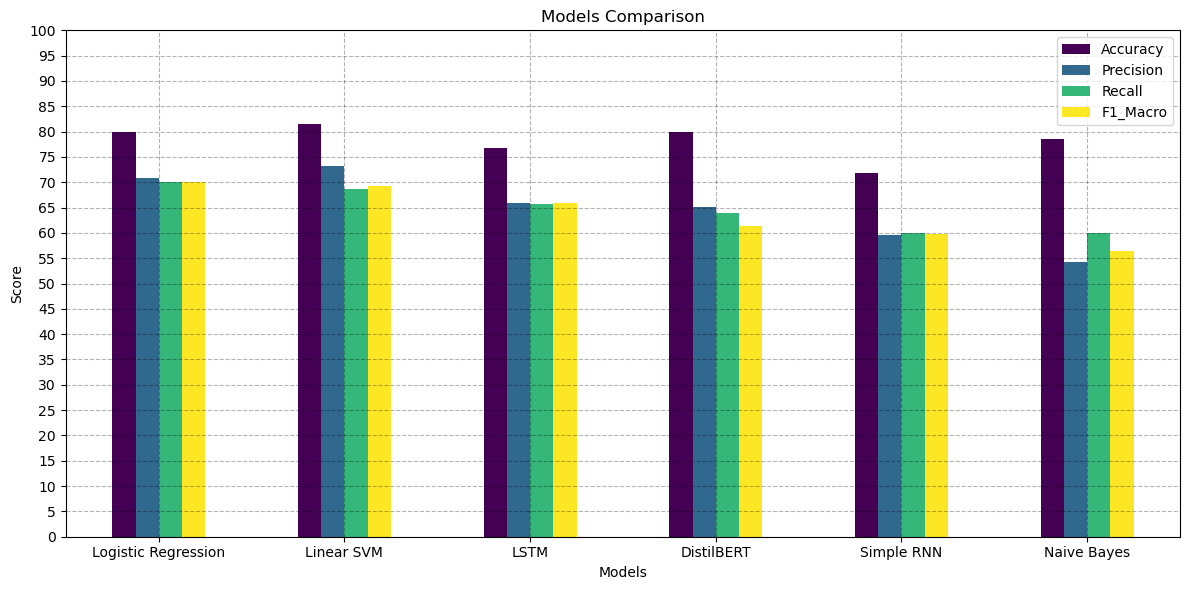

In [79]:
final_comparison_df.plot(kind= 'bar', figsize= (12, 6), colormap= 'viridis', rot= 0)
plt.title('Models Comparison')
plt.xlabel('Models')
plt.ylabel('Score')
plt.yticks(np.arange(0, 101, 5))
plt.grid(color= 'black', alpha= 0.3, linestyle= '--')
plt.tight_layout()
plt.show()

In [80]:
# get the best model
final_best_model= final_comparison_df.iloc[0]
final_best_model

Accuracy     79.86
Precision    70.86
Recall       70.04
F1_Macro     70.14
Name: Logistic Regression, dtype: float64

## Save the best model for deployment

We save both the trained model AND the fitted `TfidfVectorizer` — the
vectorizer is just as essential as the model itself, because at
prediction time we need to convert new raw text into the exact same
5000-dimension TF-IDF space the model was trained on. This is what the
Streamlit app (`Sentiment_App/app.py`) will load.


In [81]:
# craete pipeline
from sklearn.pipeline import Pipeline
lr_pipeline= Pipeline([
    ('tfidf', tfidf),
    ('model', lr_model)
])

# testing the pipeline before saving
test_reviews= [
     "This product is amazing and I love it.",
     "The product is okay, nothing special.",
     "Terrible product. It stopped working."
]

for review in test_reviews:
    test_cleaned_review= clean_text(review)
    test_prediction= lr_pipeline.predict([test_cleaned_review])[0]
    
    print(f"{test_prediction} --> {review}")
    print('-'*60)

positive --> This product is amazing and I love it.
------------------------------------------------------------
negative --> The product is okay, nothing special.
------------------------------------------------------------
negative --> Terrible product. It stopped working.
------------------------------------------------------------


### Save tfidf and model as pipeline

In [83]:
# save the pipeline
import os
import joblib
joblib.dump(lr_pipeline, 'lr_model.pkl')

# check 
print('Model saved:', os.path.exists('lr_model.pkl'))

# test that saved model
loaded_model= joblib.load('lr_model.pkl')

rev= "The product quality is excellent."
cln_txt= clean_text(rev)
pred= loaded_model.predict([cln_txt])[0]

print(f"\n{pred} --> {rev}")

Model saved: True

positive --> The product quality is excellent.


### Create preprocessing.py

In [84]:
%%writefile preprocessing.py

import re
import string
import emoji
import contractions
import nltk
from nltk.corpus import stopwords

try:
    stopwords.words("english")
except LookupError:
    nltk.download("stopwords")

# Keep negation words because they carry sentiment
keep_words = {"not", "no", "nor", "do", "does", "did"}
stop_words2 = set(stopwords.words("english")) - keep_words

# create clean_text function
def clean_text(text):                                                 # we are creating a function called 'clean_text' and 'text' is the input

    text= emoji.demojize(str(text))                                   # convert emojis to descriptive text
    
    text= str(text).lower()                                           # str- coverts input into string, lower()- coverts uppercase letters to lowercase

    text= contractions.fix(text)                                      # automatically expand contractions 
    
    text= re.sub(r"<.*?>", " ", text)                                 # re.sub()- regular expression, finds patter and replace it with something else
                                                                      # <.*?>: is designed to find HTML tags
    
    text= re.sub(r"http\S+|www\S+"," " , text)                        # this removes web addresses
    
    for i in string.punctuation:                                      # removing punctuations and replacing with a space
        text= text.replace(i, ' ')

    text= re.sub(r"\s+", " ", text).strip()                           # removes extra spaces

    words1= text.split()                                              # split text into words

    words2= [word for word in words1 if word not in stop_words2]      # removing stop words

    text= " ".join(words2)                                            # join words again to a single string
    
    return text                                                       # return the cleaned text

Overwriting preprocessing.py


### Create app.py

In [85]:
%%writefile app.py
import streamlit as st
import joblib
from preprocessing import clean_text

# ---------- Page settings ----------
st.set_page_config(
    page_title="Review Sentiment",
    page_icon="💬",
    layout="centered",
)


# ---------- Model ----------
@st.cache_resource
def load_model():
    return joblib.load("lr_model.pkl")


model = load_model()

label_map = {0: "negative", 1: "neutral", 2: "positive"}

THEME = {
    "positive": {"emoji": "😊", "color": "#1E8E5A", "bg": "#E8F6EF", "text": "This review sounds happy with the product."},
    "neutral":  {"emoji": "😐", "color": "#B7791F", "bg": "#FFF6E0", "text": "This review is mixed or doesn't take a clear side."},
    "negative": {"emoji": "😞", "color": "#C53030", "bg": "#FDECEC", "text": "This review sounds unhappy with the product."},
}

EXAMPLES = {
    "😊 Positive": "Absolutely love this! Great quality, arrived early, and works exactly as described.",
    "😐 Neutral": "It's okay. Does the job but nothing special, and the packaging was average.",
    "😞 Negative": "Stopped working after two days. Waste of money and customer support never replied.",
}


# ---------- Styling ----------
st.markdown(
    """
    <style>
    @import url('https://fonts.googleapis.com/css2?family=DM+Sans:wght@400;500;700&display=swap');

    html, body, [class*="css"], .stApp {
        font-family: 'DM Sans', sans-serif;
    }
    .stApp { background: #F1F3F6; }
    #MainMenu, footer, header { visibility: hidden; }
    .block-container { padding-top: 1.5rem; max-width: 760px; }

    /* Header band */
    .hero {
        background: #232F3E;
        border-bottom: 5px solid #FF9900;
        border-radius: 14px;
        padding: 2rem 2rem 1.7rem 2rem;
        margin-bottom: 1.5rem;
    }
    .hero h1 {
        color: #FFFFFF;
        font-size: 2rem;
        font-weight: 700;
        margin: 0 0 .4rem 0;
        padding: 0;
        letter-spacing: -0.02em;
    }
    .hero p { color: #C9D1DB; margin: 0; font-size: 1rem; line-height: 1.5; }

    /* Input card */
    .section-title {
        font-weight: 700;
        color: #232F3E;
        font-size: 1.05rem;
        margin: .2rem 0 .5rem 0;
    }
    .stTextArea textarea {
        border-radius: 10px;
        border: 1.5px solid #CBD3DD;
        background: #FFFFFF;
        font-size: 1rem;
        line-height: 1.5;
        color: #232F3E;
    }
    .stTextArea textarea:focus {
        border-color: #FF9900;
        box-shadow: 0 0 0 3px rgba(255,153,0,.25);
    }
    .stTextArea label { display: none; }

    /* Buttons */
    div.stButton > button {
        border-radius: 999px;
        border: 1.5px solid #CBD3DD;
        background: #FFFFFF;
        color: #232F3E;
        font-weight: 500;
        padding: .35rem 1rem;
        transition: border-color .15s, background .15s;
    }
    div.stButton > button:hover {
        border-color: #FF9900;
        background: #FFF8EB;
        color: #232F3E;
    }
    div.stButton > button[kind="primary"] {
        background: #FF9900;
        border-color: #FF9900;
        color: #131A22;
        font-weight: 700;
        border-radius: 10px;
        padding: .6rem 1rem;
        font-size: 1.05rem;
    }
    div.stButton > button[kind="primary"]:hover {
        background: #F08804;
        border-color: #F08804;
        color: #131A22;
    }

    /* Result */
    .result {
        border-radius: 14px;
        padding: 1.4rem 1.5rem;
        margin-top: 1.2rem;
        display: flex;
        gap: 1rem;
        align-items: center;
    }
    .result .emoji { font-size: 3rem; line-height: 1; }
    .result .label { font-size: 1.7rem; font-weight: 700; line-height: 1.1; }
    .result .note { color: #3B4756; margin-top: .25rem; }

    /* Confidence bars */
    .bars { background: #FFFFFF; border-radius: 14px; padding: 1.1rem 1.4rem; margin-top: .9rem; }
    .bar-row { display: flex; align-items: center; gap: .8rem; margin: .5rem 0; }
    .bar-name { width: 80px; font-weight: 500; color: #232F3E; text-transform: capitalize; }
    .bar-track { flex: 1; height: 10px; background: #E6EAF0; border-radius: 999px; overflow: hidden; }
    .bar-fill { height: 100%; border-radius: 999px; }
    .bar-pct { width: 52px; text-align: right; font-weight: 700; color: #232F3E; }

    .hint { color: #6B7787; font-size: .85rem; margin-top: .3rem; }
    </style>
    """,
    unsafe_allow_html=True,
)


# ---------- Header ----------
st.markdown(
    """
    <div class="hero">
        <h1>💬 Review Sentiment</h1>
        <p>Paste a product review and find out if it reads as positive, neutral, or negative.</p>
    </div>
    """,
    unsafe_allow_html=True,
)


# ---------- Input ----------
if "review" not in st.session_state:
    st.session_state.review = ""


def set_example(text):
    st.session_state.review = text


st.markdown('<div class="section-title">Your review</div>', unsafe_allow_html=True)

review = st.text_area(
    "Enter your review:",
    key="review",
    height=150,
    placeholder="Example: I really love this product!",
)
st.markdown(
    f'<div class="hint">{len(review)} characters</div>', unsafe_allow_html=True
)

st.markdown('<div class="section-title" style="margin-top:1rem">Try an example</div>', unsafe_allow_html=True)
cols = st.columns(3)
for col, (name, text) in zip(cols, EXAMPLES.items()):
    col.button(name, on_click=set_example, args=(text,), use_container_width=True)

st.write("")
predict = st.button("Analyze sentiment", type="primary", use_container_width=True)


# ---------- Prediction ----------
if predict:
    if review.strip() == "":
        st.warning("Write or paste a review above, then select Analyze sentiment.")
    else:
        with st.spinner("Reading the review..."):
            cleaned_review = clean_text(review)
            prediction = model.predict([cleaned_review])[0]
            sentiment = label_map.get(prediction, prediction)

        t = THEME[sentiment]

        st.markdown(
            f"""
            <div class="result" style="background:{t['bg']}; border-left:6px solid {t['color']};">
                <div class="emoji">{t['emoji']}</div>
                <div>
                    <div class="label" style="color:{t['color']};">{sentiment.capitalize()}</div>
                    <div class="note">{t['text']}</div>
                </div>
            </div>
            """,
            unsafe_allow_html=True,
        )

        # Confidence bars (only if the model supports probabilities)
        if hasattr(model, "predict_proba"):
            try:
                probs = model.predict_proba([cleaned_review])[0]
                rows = ""
                for cls, p in sorted(zip(model.classes_, probs), key=lambda x: -x[1]):
                    name = label_map.get(cls, str(cls))
                    color = THEME[name]["color"] if name in THEME else "#888"
                    rows += (
                        f'<div class="bar-row">'
                        f'<div class="bar-name">{name}</div>'
                        f'<div class="bar-track"><div class="bar-fill" '
                        f'style="width:{p*100:.1f}%; background:{color};"></div></div>'
                        f'<div class="bar-pct">{p*100:.0f}%</div>'
                        f"</div>"
                    )
                st.markdown(
                    f'<div class="bars"><div class="section-title">Model confidence</div>{rows}</div>',
                    unsafe_allow_html=True,
                )
            except Exception:
                pass

Overwriting app.py


### Create requirements.txt

In [86]:
import sklearn
print(sklearn.__version__)

1.7.1


In [87]:
%%writefile requirements.txt
nltk
emoji
contractions
streamlit
scikit-learn== 1.7.1
joblib

Overwriting requirements.txt


### Create README file

In [88]:
%%writefile README.md

# Amazon Review Sentiment Analysis

## 📌 Project Overview

This project is an **Amazon Review Sentiment Analysis System** that automatically classifies customer reviews into three sentiment categories:

* Negative
* Neutral
* Positive

The project explores and compares **Machine Learning, Deep Learning, and Transformer-based NLP models**. The selected Logistic Regression model is integrated into a Streamlit web application for real-time sentiment prediction.

---

## 🎯 Business Problem

E-commerce companies receive a large number of customer reviews every day.

Manually analyzing these reviews is time-consuming and difficult. An automated sentiment analysis system can help businesses understand customer opinions at scale.

### Business Benefits

* Understand customer opinions
* Identify negative customer feedback
* Monitor customer satisfaction
* Analyze large volumes of reviews automatically
* Support data-driven business decisions
* Quickly identify areas requiring improvement

---

## 📊 Dataset

The project uses an **Amazon product review dataset** for sentiment classification.

The dataset contains customer review text and sentiment information prepared for a three-class classification problem.

### Dataset Classes

The sentiment labels were manually encoded as follows:

| Label | Sentiment |
| ----: | --------- |
|     0 | Negative  |
|     1 | Neutral   |
|     2 | Positive  |

The dataset used in the project is included as:

```text
dataset.xlsx
```

---

## 🧹 Text Preprocessing

The review text is processed using a custom `clean_text()` function.

The preprocessing step prepares raw customer reviews before they are passed to the machine learning model.

The **same preprocessing function used during model training is used during deployment** to ensure consistency between training data and new reviews.

### Preprocessing Pipeline

```text
Raw Review
     ↓
Text Cleaning
     ↓
Cleaned Review
     ↓
TF-IDF Vectorization
     ↓
Machine Learning Model
     ↓
Sentiment Prediction
```

The preprocessing function is stored separately in:

```text
preprocessing.py
```

---

## 🤖 Models Compared

Several Machine Learning, Deep Learning, and Transformer-based models were evaluated.

### Machine Learning Models

* Logistic Regression
* Linear SVM
* Naive Bayes

### Deep Learning Models

* Simple RNN
* LSTM

### Transformer Model

* DistilBERT

---

## 📈 Model Comparison

The following table shows the evaluation results obtained from the project.

| Model                   |   Accuracy |  Precision | Recall | F1 Macro |
| ----------------------- | ---------: | ---------: | -----: | -------: |
| **Logistic Regression** |     79.86% |     70.86% | 70.04% |**70.14%**|
| **Linear SVM**          | **81.60%** |     73.16% | 68.76% |   69.22% |
| **DistilBERT**          | **81.94%** | **73.81%** | 65.95% |   64.04% |
| **Naive Bayes**         |     78.47% |     54.18% | 59.97% |   56.49% |
| **Simple RNN**          |     50.69% |     16.90% | 33.33% |   22.43% |
| **LSTM**                |     50.69% |     16.90% | 33.33% |   22.43% |

### 🏆 Model Analysis

Based on the evaluation results:

* **DistilBERT achieved the highest accuracy: 81.94%**
* **Linear SVM achieved 81.60% accuracy**
* **Logistic Regression achieved 79.86% accuracy**
* DistilBERT also achieved the highest precision at **73.81%**
* Logistic Regression provides a strong balance between performance, simplicity, and computational requirements.
* Simple RNN and LSTM achieved significantly lower performance on this dataset.

### 🚀 Selected Deployment Model

Although DistilBERT achieved the highest overall accuracy, **Logistic Regression was selected for deployment** because it provides:

* Highest f1_macro    
* Fast prediction
* Lower computational requirements
* Simple deployment
* Efficient CPU execution
* Easy integration with TF-IDF
* Good classification performance

The deployed model consists of a **TF-IDF Vectorizer + Logistic Regression** pipeline.

---

## 🔗 Final Machine Learning Pipeline

The deployed pipeline works as follows:

```text
User enters Amazon Review
          ↓
     clean_text()
          ↓
     TF-IDF Vectorizer
          ↓
   Logistic Regression
          ↓
    Prediction: 0/1/2
          ↓
     Sentiment Mapping
          ↓
Negative / Neutral / Positive
```

---

## 🚀 Streamlit Application

The trained Logistic Regression pipeline is deployed using **Streamlit**.

The application allows users to enter an Amazon review and receive a sentiment prediction in real time.

### Application Workflow

1. User enters a review.
2. The review is passed through `clean_text()`.
3. The cleaned text is transformed using the saved TF-IDF vectorizer.
4. Logistic Regression predicts the sentiment class.
5. The numeric prediction is converted into the corresponding sentiment.
6. The result is displayed in the Streamlit application.

---

## 📁 Project Structure

```text
Sentiment_App/
│
├── app.py
│
├── preprocessing.py
│
├── lr_model.pkl
│
├── dataset.xlsx
│
├── requirements.txt
│
└── README.md
```

### File Description

| File                  | Description                                    |
| --------------------- | ---------------------------------------------- |
| `app.py`              | Streamlit web application                      |
| `preprocessing.py`    | Text preprocessing and `clean_text()` function |
| `sentiment_model.pkl` | Saved TF-IDF + Logistic Regression pipeline    |
| `dataset.xlsx`        | Amazon review dataset                          |
| `requirements.txt`    | Required Python packages                       |
| `README.md`           | Project documentation                          |

---

## ⚙️ Installation

### 1. Activate the Python Environment

If using Anaconda:

```bash
conda activate ml_env
```

### 2. Install Required Libraries

```bash
pip install -r requirements.txt
```

---

## ▶️ Run the Streamlit Application

Navigate to the project directory:

```bash
cd Amazon_Sentiment_App
```

Run:

```bash
streamlit run app.py
```

The Streamlit application will start and provide a local URL such as:

```text
http://localhost:8501
```

Open the URL in a web browser to use the application.

---

## 🧪 Example Predictions

### Positive Review

```text
I absolutely love this product! Amazing quality.
```

Expected sentiment:

```text
POSITIVE
```

### Negative Review

```text
Very bad product. I am disappointed with the quality.
```

Expected sentiment:

```text
NEGATIVE
```

### Neutral Review

```text
The product is okay and works as expected.
```

Expected sentiment:

```text
NEUTRAL
```

---

## 💾 Model Saving

The TF-IDF vectorizer and Logistic Regression model are combined into a single Scikit-learn Pipeline.

```python
from sklearn.pipeline import Pipeline

sentiment_pipeline = Pipeline([
    ("tfidf", tfidf),
    ("model", lr_model)
])
```

The trained pipeline is saved using Joblib:

```python
joblib.dump(sentiment_pipeline, "sentiment_model.pkl")
```

This allows the Streamlit application to load the trained model without retraining it.

---

## 🔄 Prediction on New Reviews

When a new review is entered into the Streamlit application:

```text
New Review
    ↓
clean_text()
    ↓
Saved TF-IDF
    ↓
Saved Logistic Regression
    ↓
0 / 1 / 2
    ↓
Sentiment
```

The model does **not** need to be trained again when making predictions.

---

## 📌 Important Note

The `clean_text()` function used during deployment should remain the **same as the function used during model training**.

Changing the preprocessing logic after training can cause differences between training data and new reviews and may affect prediction performance.

---

## 🛠️ Technologies Used

* Python
* Pandas
* NumPy
* Scikit-learn
* Natural Language Processing (NLP)
* TF-IDF
* Logistic Regression
* Linear SVM
* Naive Bayes
* Simple RNN
* LSTM
* DistilBERT
* Hugging Face Transformers
* PyTorch
* Streamlit
* Joblib
* Jupyter Notebook

---

## 🎓 Project Type

**Natural Language Processing (NLP) | Sentiment Analysis | Machine Learning | Deep Learning | Transformer | Streamlit Deployment**

---

## 👨‍💻 Conclusion

This project demonstrates how customer reviews can be automatically classified using different NLP and machine learning approaches.

The experiments show that Transformer-based DistilBERT achieved the highest accuracy, while Logistic Regression provided a strong and computationally efficient solution for deployment.

The final Streamlit application allows users to enter new Amazon reviews and receive real-time sentiment predictions.


Overwriting README.md


## Final Conclusion

### Objective
Classify Amazon customer reviews as **negative, neutral, or positive** and deploy the best model as a working web app.

### What we did
- Analysed 1,440 reviews. Sentiment labels were derived from star ratings (1–2 negative, 3 neutral, 4–5 positive).
- The classes are imbalanced (positive 50.6%, negative 35.6%, neutral 13.8%), so we used stratified splits, class weights, and **macro-F1** as the main metric.
- Cleaned the text (emoji conversion, contraction expansion, HTML/URL/punctuation removal, stop-word removal while keeping negations).
- Compared three model families on the same 80/20 split: TF-IDF with classical ML, deep learning (SimpleRNN and LSTM), and a fine-tuned DistilBERT transformer.

### Results

| Model | Accuracy | Precision (macro) | Recall (macro) | F1 (macro) |
|---|---|---|---|---|
| **Logistic Regression** | 79.86% | 70.86% | 70.04% | **70.14%** |
| Linear SVM | 81.60% | 73.16% | 68.76% | 69.22% |
| DistilBERT | 82.29% | 73.40% | 68.50% | 68.17% |
| LSTM | 76.74% | 65.88% | 65.78% | 65.82% |
| Simple RNN | 71.88% | 59.64% | 59.98% | 59.78% |
| Naive Bayes | 78.47% | 54.18% | 59.97% | 56.49% |

### Key findings
1. **Logistic Regression is the best overall model** by macro-F1 (0.701). The top three models are close, and DistilBERT and Linear SVM have slightly higher accuracy and precision. Logistic Regression is also the simplest and fastest of them.
2. **Proper training mattered for deep learning.** The first RNN and LSTM predicted almost only "positive" (macro-F1 about 0.22). Masking padding, applying class weights, adding dropout, and early stopping raised them to 0.60 (RNN) and 0.66 (LSTM). The LSTM clearly beats the RNN, but both stay below the TF-IDF models.
3. **Neutral reviews are the main weakness of every model.** Logistic Regression reaches only 0.39 F1 on neutral, and the LSTM's neutral recall is 27.5%. Three-star reviews mix praise and complaints and are the smallest class (13.8%).
4. **Small data favours simple models.** With 1,440 reviews, a TF-IDF model matches or beats a pretrained transformer and the neural networks, while being faster and easier to interpret.

### Deployment decision
We deployed **TF-IDF + Logistic Regression** as a single scikit-learn pipeline in a Streamlit app. It was chosen for its best macro-F1, fast CPU-only predictions, and simple deployment. The app uses the same `clean_text()` function as training, so training and prediction stay consistent.

### Limitations
- Labels come from star ratings, which only approximate the true sentiment of the text.
- The test set has only 288 reviews, and neural-network scores vary slightly between runs, so small differences between models should not be over-interpreted.
- Sarcasm and mixed opinions are often misclassified, especially as positive or negative instead of neutral.

### Future improvements
- Collect more reviews, especially neutral ones.
- Fine-tune DistilBERT with class weights and more epochs, and set a fixed seed.
- Try a Bidirectional LSTM or GRU, or pretrained embeddings such as GloVe.
- Validate with stratified cross-validation and analyse misclassified neutral reviews.
- Calibrate the decision threshold for the neutral class.

### Final takeaway
The best solution here is not the most complex one. A cleaned, class-weighted TF-IDF + Logistic Regression model gives the most balanced performance on this dataset, and it is now available as a deployable app. More data and better handling of neutral reviews are the clearest ways to improve it further.